# Notebook 2 - Scarcity Regimes and System Tightness

## Objective

This notebook investigates the physical and operational conditions associated with extreme electricity prices in Alberta.

Notebook 1 established how Alberta’s electricity market changed and how its principal variables behave. This notebook narrows the analysis to periods of system stress. It evaluates whether scarcity is associated with: limited reported capacity margin; reduced available supply margin; reduced thermal headroom; elevated generation outages; dependence on intertie imports; and combinations of these operating conditions.

The analysis distinguishes structural capacity from operational availability. Installed capacity measures the reported size of the generation fleet, whereas available capacity measures the supply reported as available during a particular hour. Neither measure is equivalent to operating reserve. The margin variables developed here should therefore be interpreted as system-tightness proxies rather than official reserve measures.

Price thresholds are used to identify the market outcomes associated with scarcity. These thresholds do not define physical scarcity by themselves. Instead, the notebook examines which physical conditions tend to accompany progressively more extreme price outcomes.

The analysis is descriptive and contemporaneous. It does not establish causal effects or out-of-sample forecasting performance.

## 1. Environment, Data, and Analytical Definitions

### 1.1 Imports and canonical dataset

The notebook uses the canonical hourly master dataset produced by the project pipeline. The master DataFrame remains authoritative. Notebook-specific variables are stored separately in scarcity_features.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path: 
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f"Canonical master loaded: "
    f"{master.shape[0]:,} rows × {master.shape[1]:,} columns"
)

Canonical master loaded: 96,425 rows × 494 columns


### 1.2 Study period and input validation

The main analysis covers Alberta operating years 2015-2025. Timestamp integrity, annual coverage, required columns, and missingness in the principal Notebook 2 variables are checked before any scarcity features are constructed.

Missing intertie observations are retained as missing rather than interpreted as zero imports. Technology-level availability field are also treated cautiously because AESO technology classifications and reporting boundaries changed during the study period. 

In [2]:
# ---------------------------------------------------------------------
# Define the study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025
ALBERTA_TIMEZONE = "America/Edmonton"

PRICE_THRESHOLDS = [100, 300, 500, 900]
PRIMARY_SCARCITY_THRESHOLD = 500

THERMAL_TECHNOLOGIES = [
    "coal",
    "cogeneration",
    "combined_cycle",
    "dual_fuel",
    "gas_fired_steam",
    "simple_cycle",
]

THERMAL_AVAILABILITY_COLUMNS = [
    f"{technology}_system_available"
    for technology in THERMAL_TECHNOLOGIES
]

THERMAL_GENERATION_COLUMNS = [
    f"{technology}_system_generation"
    for technology in THERMAL_TECHNOLOGIES
]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "year_alberta",
    "pool_price",
    "ail_mw",
    "total_system_capacity",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "thermal_outage_mw",
    "renewable_outage_mw",
    "simple_cycle_outage",
    "combined_cycle_outage",
    "cogeneration_outage",
    "total_imports_mw",
    "total_exports_mw",
    "net_imports_mw",
    "wind_system_generation",
    "solar_system_generation",
    "atc_sk_import",
    "atc_wecc_import",
    "ttc_sk_import",
    "ttc_wecc_import",
] + THERMAL_AVAILABILITY_COLUMNS + THERMAL_GENERATION_COLUMNS

missing_required_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_required_columns:
    raise ValueError(
        "Master dataset is missing Notebook 2 columns: "
        f"{missing_required_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(
    master["timestamp_utc"],
    utc=True,
)

master = (
    master
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

master = (
    master.loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    f"Selected period: "
    f"{master['timestamp_alberta'].min()} to "
    f"{master['timestamp_alberta'].max()}"
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 16:00:00-07:00


In [3]:
# ---------------------------------------------------------------------
# Audit annual coverage and decision-relevant missingness
# ---------------------------------------------------------------------

study_years = pd.Index(
    range(STUDY_START_YEAR, STUDY_END_YEAR + 1),
    name="year_alberta",
)

observed_hours = (
    master
    .groupby("year_alberta")
    .size()
    .reindex(study_years, fill_value=0)
)

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start=f"{year}-01-01",
                end=f"{year + 1}-01-01",
                inclusive="left",
                freq="h",
                tz=ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name="expected_hours",
)

expected_hours.index.name = "year_alberta"

annual_coverage = pd.concat(
    [
        expected_hours,
        observed_hours.rename("observed_hours"),
    ],
    axis=1,
)

annual_coverage["unobserved_hours"] = (
    annual_coverage["expected_hours"]
    - annual_coverage["observed_hours"]
)

annual_coverage["coverage_pct"] = (
    annual_coverage["observed_hours"]
    / annual_coverage["expected_hours"]
    * 100
)

AUDIT_COLUMNS = [
    "pool_price",
    "ail_mw",
    "total_system_capacity",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "thermal_outage_mw",
    "net_imports_mw",
    "wind_system_generation",
    "solar_system_generation",
    "atc_sk_import",
    "atc_wecc_import",
]

input_missingness = pd.DataFrame(
    {
        "missing_hours":
            master[AUDIT_COLUMNS].isna().sum(),

        "missing_pct":
            master[AUDIT_COLUMNS].isna().mean() * 100,

        "first_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].min()
            for column in AUDIT_COLUMNS
        ],

        "last_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].max()
            for column in AUDIT_COLUMNS
        ],
    },
    index=AUDIT_COLUMNS,
)

print("Annual study-period coverage")
display(annual_coverage.round({"coverage_pct": 3}))

print("Missingness and reporting windows")
display(input_missingness.round({"missing_pct": 3}))

Annual study-period coverage


,expected_hours,observed_hours,unobserved_hours,coverage_pct
year_alberta,,,,
2015,8760,8760,0,100.00
2016,8784,8784,0,100.00
2017,8760,8760,0,100.00
2018,8760,8760,0,100.00
2019,8760,8760,0,100.00
2020,8784,8784,0,100.00
2021,8760,8760,0,100.00
2022,8760,8760,0,100.00
2023,8760,8760,0,100.00


Missingness and reporting windows


,missing_hours,missing_pct,first_reported,last_reported
pool_price,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
ail_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_capacity,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_available,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_system_generation,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
total_outage_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
thermal_outage_mw,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
net_imports_mw,3666,3.802,2015-01-01 00:00:00-07:00,2025-07-31 23:00:00-06:00
wind_system_generation,0,0.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00
solar_system_generation,25656,26.607,2017-12-05 00:00:00-07:00,2025-12-31 16:00:00-07:00


In [4]:
# ---------------------------------------------------------------------
# Validate the solar reporting boundary
# ---------------------------------------------------------------------

solar_generation = master[
    "solar_system_generation"
]

solar_reported = solar_generation.notna()

solar_first_reported = master.loc[
    solar_reported,
    "timestamp_alberta",
].min()

solar_missing_before_reporting = (
    solar_generation.isna()
    & master["timestamp_alberta"].lt(
        solar_first_reported
    )
)

solar_missing_after_reporting = (
    solar_generation.isna()
    & master["timestamp_alberta"].ge(
        solar_first_reported
    )
)

solar_reporting_audit = pd.DataFrame([
    {
        "first_reported":
            solar_first_reported,
        "missing_before_reporting":
            int(
                solar_missing_before_reporting.sum()
            ),
        "missing_after_reporting":
            int(
                solar_missing_after_reporting.sum()
            ),
        "total_missing":
            int(solar_generation.isna().sum()),
    }
])

assert (
    solar_missing_after_reporting.sum() == 0
), (
    "Solar generation contains missing values "
    "after its reporting period begins."
)

assert (
    solar_missing_before_reporting.sum()
    == solar_generation.isna().sum()
), (
    "Not all missing solar observations occur "
    "before the reporting boundary."
)

display(solar_reporting_audit)

,first_reported,missing_before_reporting,missing_after_reporting,total_missing
0,2017-12-05 00:00:00-07:00,25656,0,25656


> Solar generation contains 25,656 missing observations, all of which occur before reporting begins on December 5, 2017. No solar observations are missing after that boundary. Treating pre-reporting solar generation as zero is therefore reasonable for the historical net-load construction.

> Dual-fuel availability and generation contain a 5,783-hour internal reporting gap during 2022. During those hours, the reported thermal aggregation includes the other available technology-level series but omits dual-fuel values; no missing values are imputed. Excluding the affected hours changes thermal headroom’s ROC-AUC only from 0.898 to 0.899, indicating that the principal thermal-headroom result is robust to the reporting gap.

### 1.3 Structural market regimes

Alberta’s generation fleet changed substantially during the study period. Relationships estimated over the full sample may therefore conceal important differences between earlier and later operating environments.

The following externally defined calendar regimes are used:

- **2015–2017:** coal-dominant system;
- **2018–2021:** coal-to-gas transition;
- **2022–2024:** late coal exit and renewable buildout; and
- **2025:** coal-free gas-renewable system.

These regimes are based on the generation transition documented in Notebook 1. They are not defined using the price outcome examined in this notebook.

In [5]:
# ---------------------------------------------------------------------
# Define structural generation regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    'Coal-dominant',
    'Coal-to-gas transition',
    'Late coal exit and renewable buildout',
    'Coal-free gas-renewable system',
]

structural_regime = pd.Categorical(
    np.select(
        [
            master['year_alberta'].le(2017),
            master['year_alberta'].le(2021),
            master['year_alberta'].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default = STRUCTURAL_REGIME_ORDER[3],
    ),
    categories = STRUCTURAL_REGIME_ORDER,
    ordered = True,
)

structural_regime_summary = (
    pd.DataFrame({
        'structural_regime': structural_regime,
        'year_alberta': master['year_alberta'],
        'pool_price': master['pool_price'],
    })
    .groupby('structural_regime', observed = True)
    .agg(
        start_year = ('year_alberta', 'min'),
        end_year = ('year_alberta', 'max'),
        observations = ('year_alberta', 'size'),
        average_price = ('pool_price', 'mean'),
    )
)

display(structural_regime_summary.round(2))

,start_year,end_year,observations,average_price
structural_regime,,,,
Coal-dominant,2015,2017,26304,24.59
Coal-to-gas transition,2018,2021,35064,63.46
Late coal exit and renewable buildout,2022,2024,26304,119.57
Coal-free gas-renewable system,2025,2025,8753,43.69


### 1.4 Analytical Variables

The notebook separates several related concepts:

- **Net load:** Alberta Internal Load minus wind and solar generation.
- **Reported capacity margin:** reported system capacity minus load.
- **Domestic available margin:** reported available system supply minus load.
- **Intertie-supported margin:** domestic available margin plus observed net imports.
- **Reported supply headroom:** available system supply minus actual system generation.
- **Thermal headroom:** reported thermal availability minus actual thermal generation.
- **Outage burden:** unavailable generation in MW and relative to reported capacity.
- **Import capability:** reported Saskatchewan and WECC import available-transfer capability.

These are analytical proxies. In particular, domestic available margin and reported supply headroom should not be described as official AESO operating reserve or supply cushion.

In [6]:
# ---------------------------------------------------------------------
# Construct Notebook 2 variables without modifying master
# ---------------------------------------------------------------------

scarcity_features = pd.DataFrame(index=master.index)

for threshold in PRICE_THRESHOLDS:
    scarcity_features[
        f"price_at_or_above_{threshold}"
    ] = master["pool_price"].ge(threshold)

scarcity_features["price_regime"] = pd.cut(
    master["pool_price"],
    bins=[
        -np.inf,
        100,
        300,
        500,
        900,
        np.inf,
    ],
    labels=[
        "Below $100",
        "$100–$299",
        "$300–$499",
        "$500–$899",
        "$900+",
    ],
    right=False,
)

# Identify internal dual-fuel missingness inside
# the technology's observed reporting window.
DUAL_FUEL_COLUMNS = [
    "dual_fuel_system_available",
    "dual_fuel_system_generation",
]

dual_fuel_fully_reported = (
    master[DUAL_FUEL_COLUMNS]
    .notna()
    .all(axis=1)
)

dual_fuel_first_reported = master.loc[
    dual_fuel_fully_reported,
    "timestamp_alberta",
].min()

dual_fuel_last_reported = master.loc[
    dual_fuel_fully_reported,
    "timestamp_alberta",
].max()

dual_fuel_reporting_window = (
    master["timestamp_alberta"]
    .between(
        dual_fuel_first_reported,
        dual_fuel_last_reported,
    )
)

scarcity_features["dual_fuel_reporting_gap"] = (
    dual_fuel_reporting_window
    & master[DUAL_FUEL_COLUMNS].isna().any(axis=1)
)

# Pre-reporting solar observations are treated as zero.
# The coverage audit should verify that solar has no
# missing observations after reporting begins.
scarcity_features[
    "variable_renewable_generation_mw"
] = (
    master["wind_system_generation"]
    + master["solar_system_generation"].fillna(0)
)

scarcity_features["net_load_mw"] = (
    master["ail_mw"]
    - scarcity_features[
        "variable_renewable_generation_mw"
    ]
)

# Missing technology-level values are omitted from the
# thermal total rather than imputed.
scarcity_features[
    "reported_thermal_available_mw"
] = (
    master[THERMAL_AVAILABILITY_COLUMNS]
    .sum(axis=1, min_count=1)
)

scarcity_features[
    "reported_thermal_generation_mw"
] = (
    master[THERMAL_GENERATION_COLUMNS]
    .sum(axis=1, min_count=1)
)

scarcity_features["thermal_headroom_mw"] = (
    scarcity_features[
        "reported_thermal_available_mw"
    ]
    - scarcity_features[
        "reported_thermal_generation_mw"
    ]
)

scarcity_features["thermal_utilization_pct"] = (
    scarcity_features[
        "reported_thermal_generation_mw"
    ]
    / scarcity_features[
        "reported_thermal_available_mw"
    ].replace(0, np.nan)
    * 100
)

scarcity_features["reported_capacity_margin_mw"] = (
    master["total_system_capacity"]
    - master["ail_mw"]
)

scarcity_features[
    "domestic_available_margin_mw"
] = (
    master["total_system_available"]
    - master["ail_mw"]
)

scarcity_features[
    "intertie_supported_margin_mw"
] = (
    scarcity_features[
        "domestic_available_margin_mw"
    ]
    + master["net_imports_mw"]
)

scarcity_features[
    "reported_supply_headroom_mw"
] = (
    master["total_system_available"]
    - master["total_system_generation"]
)

scarcity_features[
    "available_margin_pct_of_load"
] = (
    scarcity_features[
        "domestic_available_margin_mw"
    ]
    / master["ail_mw"].replace(0, np.nan)
    * 100
)

scarcity_features[
    "outage_share_of_capacity_pct"
] = (
    master["total_outage_mw"]
    / master[
        "total_system_capacity"
    ].replace(0, np.nan)
    * 100
)

scarcity_features["import_atc_mw"] = (
    master["atc_sk_import"]
    + master["atc_wecc_import"]
)

scarcity_features["import_ttc_mw"] = (
    master["ttc_sk_import"]
    + master["ttc_wecc_import"]
)

scarcity_features[
    "net_import_share_of_load_pct"
] = (
    master["net_imports_mw"]
    / master["ail_mw"].replace(0, np.nan)
    * 100
)

In [7]:
# ---------------------------------------------------------------------
# Helper functions for percentiles, deciles, and comparisons
# ---------------------------------------------------------------------

def within_year_percentile(values):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
    })

    return (
        frame
        .groupby("year_alberta")["value"]
        .rank(method="average", pct=True)
    )

def percentile_to_decile(percentile):
    return (
        np.floor(percentile * 10)
        .clip(upper=9)
        .astype("Int64")
    )

def compare_event_means(series_by_label, event):
    values = pd.DataFrame(series_by_label)

    result = pd.DataFrame({
        "normal_mean": values.loc[~event].mean(),
        "scarcity_mean": values.loc[event].mean(),
        "normal_median": values.loc[~event].median(),
        "scarcity_median": values.loc[event].median(),
    })

    result["mean_difference"] = (
        result["scarcity_mean"]
        - result["normal_mean"]
    )

    result["mean_pct_difference"] = (
        result["mean_difference"]
        / result["normal_mean"].replace(0, np.nan)
        * 100
    )

    return result

PERCENTILE_FEATURES = {
    "load": master["ail_mw"],
    "net_load": scarcity_features["net_load_mw"],
    "available_margin": scarcity_features["domestic_available_margin_mw"],
    "thermal_headroom": scarcity_features["thermal_headroom_mw"],
    "total_outage": master["total_outage_mw"],
    "net_imports": master["net_imports_mw"],
    "import_capability": scarcity_features["import_atc_mw"],
}

for feature_name, values in PERCENTILE_FEATURES.items():
    percentile_column = (
        f"{feature_name}_percentile_within_year"
    )
    decile_column = f"{feature_name}_decile"

    scarcity_features[percentile_column] = (
        within_year_percentile(values)
    )

    scarcity_features[decile_column] = (
        percentile_to_decile(
            scarcity_features[percentile_column]
        )
    )

In [8]:
# ---------------------------------------------------------------------
# Define interpretable operating states
# ---------------------------------------------------------------------

MARGIN_STATE_ORDER = [
    "Critical",
    "Tight",
    "Balanced",
    "Loose",
]

margin_percentile = scarcity_features[
    "available_margin_percentile_within_year"
]

scarcity_features["margin_state"] = pd.cut(
    margin_percentile,
    bins=[
        0.00,
        0.05,
        0.20,
        0.80,
        1.00,
    ],
    labels=MARGIN_STATE_ORDER,
    include_lowest=True,
    ordered=True,
)


# ---------------------------------------------------------------------
# Outage states
# ---------------------------------------------------------------------

OUTAGE_STATE_ORDER = [
    "Lower outage",
    "High outage",
]

outage_percentile = scarcity_features[
    "total_outage_percentile_within_year"
]

scarcity_features["outage_state"] = pd.Categorical(
    np.where(
        outage_percentile.ge(0.80),
        "High outage",
        "Lower outage",
    ),
    categories=OUTAGE_STATE_ORDER,
    ordered=True,
)


# ---------------------------------------------------------------------
# Import-capability states
# ---------------------------------------------------------------------

CAPABILITY_STATE_ORDER = [
    "Constrained",
    "Typical",
    "High capability",
]

capability_percentile = scarcity_features[
    "import_capability_percentile_within_year"
]

scarcity_features["capability_state"] = pd.cut(
    capability_percentile,
    bins=[
        0.00,
        0.20,
        0.80,
        1.00,
    ],
    labels=CAPABILITY_STATE_ORDER,
    include_lowest=True,
    ordered=True,
)


# ---------------------------------------------------------------------
# Observed intertie-flow states
# ---------------------------------------------------------------------

FLOW_STATE_ORDER = [
    "Net exporting",
    "Balanced",
    "Net importing",
    "Not reported",
]

intertie_flow_state = np.select(
    [
        master["net_imports_mw"].isna(),
        master["net_imports_mw"].lt(0),
        master["net_imports_mw"].gt(0),
    ],
    [
        "Not reported",
        "Net exporting",
        "Net importing",
    ],
    default="Balanced",
)

scarcity_features["intertie_flow_state"] = pd.Categorical(
    intertie_flow_state,
    categories=FLOW_STATE_ORDER,
    ordered=True,
)

display(scarcity_features.head())

,price_at_or_above_100,price_at_or_above_300,price_at_or_above_500,price_at_or_above_900,price_regime,dual_fuel_reporting_gap,variable_renewable_generation_mw,net_load_mw,reported_thermal_available_mw,reported_thermal_generation_mw,thermal_headroom_mw,thermal_utilization_pct,reported_capacity_margin_mw,domestic_available_margin_mw,intertie_supported_margin_mw,reported_supply_headroom_mw,available_margin_pct_of_load,outage_share_of_capacity_pct,import_atc_mw,import_ttc_mw,net_import_share_of_load_pct,load_percentile_within_year,load_decile,net_load_percentile_within_year,net_load_decile,available_margin_percentile_within_year,available_margin_decile,thermal_headroom_percentile_within_year,thermal_headroom_decile,total_outage_percentile_within_year,total_outage_decile,net_imports_percentile_within_year,net_imports_decile,import_capability_percentile_within_year,import_capability_decile,margin_state,outage_state,capability_state,intertie_flow_state
0,False,False,False,False,Below $100,False,862.961868,8347.038132,9941.0,6582.944677,3358.055323,66.220146,6324.5,1624.0,889.0,3183.562894,17.633008,21.161286,765.0,830.0,-7.980456,0.522374,5,0.353995,3,0.196176,1,0.415183,4,0.435788,4,0.002055,0,0.277055,2,Tight,Lower outage,Typical,Net exporting
1,False,False,False,False,Below $100,False,926.189480,8118.810520,9827.0,6413.605041,3413.394959,65.265137,6489.5,1677.0,942.0,3196.657922,18.540630,21.882262,765.0,830.0,-8.126036,0.441438,4,0.268265,2,0.205137,2,0.446689,4,0.509646,5,0.002055,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
2,False,False,False,False,Below $100,False,823.660797,8015.339203,10172.0,5989.258194,4182.741806,58.879849,6695.5,2228.0,1878.0,4090.841863,25.206471,19.661399,765.0,830.0,-3.959724,0.343379,3,0.231849,2,0.331393,3,0.843493,8,0.304110,3,0.056164,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
3,False,False,False,False,Below $100,False,764.893106,7977.106894,10142.0,5822.894685,4319.105315,57.413673,6792.5,2295.0,2045.0,4281.283895,26.252574,19.854517,765.0,830.0,-2.859757,0.302169,3,0.219635,2,0.351712,3,0.885046,8,0.318322,3,0.092123,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting
4,False,False,False,False,Below $100,False,824.108485,7874.891515,9939.0,5719.917422,4219.082578,57.550231,6835.5,2135.0,1885.0,4119.859996,24.543051,21.161286,765.0,830.0,-2.873894,0.283733,2,0.186301,1,0.308619,3,0.854795,8,0.435788,4,0.092123,0,0.277055,2,Balanced,Lower outage,Typical,Net exporting


## 2. Scarcity Outcomes and Annual Base Rates

### 2.1 Price-Based Scarcity Definitions

Scarcity is evaluated at several thresholds:

- \$100/MWh identifies broadly elevated prices; 
- \$300/MWh identifies high-price conditions; 
- \$500/MWh is the notebook's primary scarcity thresholds; and
- \$900/MWh identifies the most extreme price outcomes. 

The \$500/MWh threshold is used for most conditional analyses because it isolates severe events while retaining enough observations for meaningful comparisons. 

These thresholds define market outcomes, not physical shortages. 

In [9]:
# ---------------------------------------------------------------------
# Summarize scarcity outcomes across thresholds
# ---------------------------------------------------------------------

event_summary = pd.DataFrame({
    'threshold': PRICE_THRESHOLDS,

    'hours': [
        scarcity_features[
            f'price_at_or_above_{threshold}'
        ].sum()
        for threshold in PRICE_THRESHOLDS
    ],

    'share_of_hours_pct': [
        scarcity_features[
            f'price_at_or_above_{threshold}'
        ].mean() * 100
        for threshold in PRICE_THRESHOLDS
    ],
})

event_summary['definition'] = [
    'Elevated price',
    'High price',
    'Primary scarcity event',
    'Extreme scarcity event',
]

display(event_summary.round(3))

,threshold,hours,share_of_hours_pct,definition
0,100,10057,10.430,Elevated price
1,300,4047,4.197,High price
2,500,2430,2.520,Primary scarcity event
3,900,422,0.438,Extreme scarcity event


### 2.2 Annual Event Base Rates

Scarcity frequency changes materially across years. Every decile, interaction, and stability analysis must therefore be interpreted relative to the base event rate in the corresponding year or structural regime. 

This prevents a year with generally frequent scarcity from dominating a pooled relationship. 

In [10]:
# ---------------------------------------------------------------------
# Calculate annual event counts and base rates
# ---------------------------------------------------------------------

annual_events = (
    pd.DataFrame({
        'year_alberta': master['year_alberta'],
        'pool_price': master['pool_price'],
        'event_300': scarcity_features['price_at_or_above_300'],
        'event_500': scarcity_features['price_at_or_above_500'],
        'event_900': scarcity_features['price_at_or_above_900'],
    })
    .groupby('year_alberta')
    .agg(
        observed_hours=("pool_price", "size"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
        hours_at_or_above_300=("event_300", "sum"),
        hours_at_or_above_500=("event_500", "sum"),
        hours_at_or_above_900=("event_900", "sum"),
        scarcity_base_rate=("event_500", "mean"),
    )
)

annual_events['scarcity_base_rate_pct'] = (
    annual_events['scarcity_base_rate'] * 100
)

display(annual_events.round(3))

,observed_hours,average_price,median_price,hours_at_or_above_300,hours_at_or_above_500,hours_at_or_above_900,scarcity_base_rate,scarcity_base_rate_pct
year_alberta,,,,,,,,
2015,8760,33.338,20.480,130,95,28,0.011,1.084
2016,8784,18.279,15.460,4,2,0,0.000,0.023
2017,8760,22.186,19.460,11,6,4,0.001,0.068
2018,8760,50.348,33.250,151,102,29,0.012,1.164
2019,8760,54.880,33.510,184,116,17,0.013,1.324
2020,8784,46.716,33.275,149,102,40,0.012,1.161
2021,8760,101.932,57.340,615,310,42,0.035,3.539
2022,8760,162.463,83.780,1194,758,111,0.087,8.653
2023,8760,133.628,57.200,1085,606,52,0.069,6.918


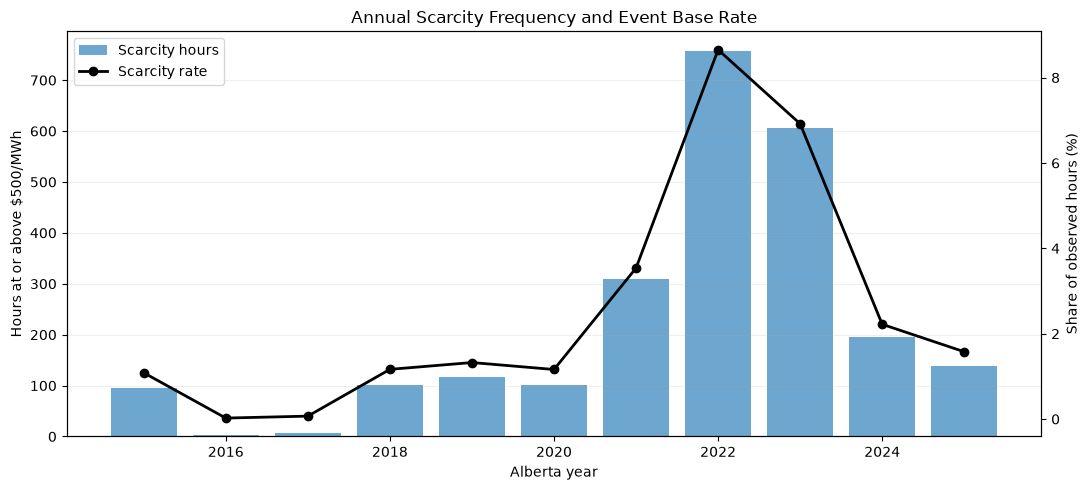

In [11]:
# ---------------------------------------------------------------------
# Plot annual scarcity count and base rate
# ---------------------------------------------------------------------

fig, ax_count = plt.subplots(figsize=(11, 5))

ax_count.bar(
    annual_events.index,
    annual_events["hours_at_or_above_500"],
    alpha=0.65,
    label="Scarcity hours",
)

ax_count.set_xlabel("Alberta year")
ax_count.set_ylabel("Hours at or above $500/MWh")

ax_rate = ax_count.twinx()

ax_rate.plot(
    annual_events.index,
    annual_events["scarcity_base_rate_pct"],
    color="black",
    marker="o",
    linewidth=2,
    label="Scarcity rate",
)

ax_rate.set_ylabel("Share of observed hours (%)")

ax_count.set_title(
    "Annual Scarcity Frequency and Event Base Rate"
)
ax_count.grid(axis="y", alpha=0.20)

lines_1, labels_1 = ax_count.get_legend_handles_labels()
lines_2, labels_2 = ax_rate.get_legend_handles_labels()

ax_count.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Annual Event Base Rates

Alberta's price environment changed sharply after 2020. Average pool price increased from \$46.72/MWh in 2020 to \$101.93/MWh in 2021, reaching \$162.46/MWh in 2022. Scarcity was most pronounced in 2022, when 758 hours reached at least \$500/MWh - an annual base rate of 8.65% - followed by 606 hours in 2023. 

Conditions moderated substantially in 2024 and 2025, with lower average and median prices and fewer scarcity hours. Nevertheless, extreme-price events remained more frequent than during the usually mild 2016-2017 period, indicating that the post-2023 market normalized without returning completely to those earlier conditions. 

## 3. Demand Pressure and Net Load

### 3.1 Load and Net-Load Distributions

Gross load measures total Alberta Internal Load. Net load subtracts contemporaneous wind and solar generation and approximates the demand that must be met by dispatchable generation, hydro, imports and other system resources. 

Notebook 2 uses actual renewable generation only to construct historical net load. Notebook 4 is responsible for explaining the weather dependence and variability of wind, solar, hydro, and demand. 

In [12]:
# ---------------------------------------------------------------------
# Compare load and net load during scarcity and normal hours
# --------------------------------------------------------------------- 

primary_event = scarcity_features[
    f'price_at_or_above_{PRIMARY_SCARCITY_THRESHOLD}'
]

demand_comparison = compare_event_means(
    {
        'Alberta Internal Load (MW)': master['ail_mw'],
        'Net load (MW)': scarcity_features['net_load_mw'],
        'Variable renewable generation (MW)': scarcity_features['variable_renewable_generation_mw'],
    },
    primary_event,
)

display(demand_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Alberta Internal Load (MW),9655.21,10458.94,9654.00,10506.50,803.74,8.32
Net load (MW),8724.58,9989.69,8741.05,9985.83,1265.11,14.50
Variable renewable generation (MW),930.62,469.25,726.81,355.80,-461.37,-49.58


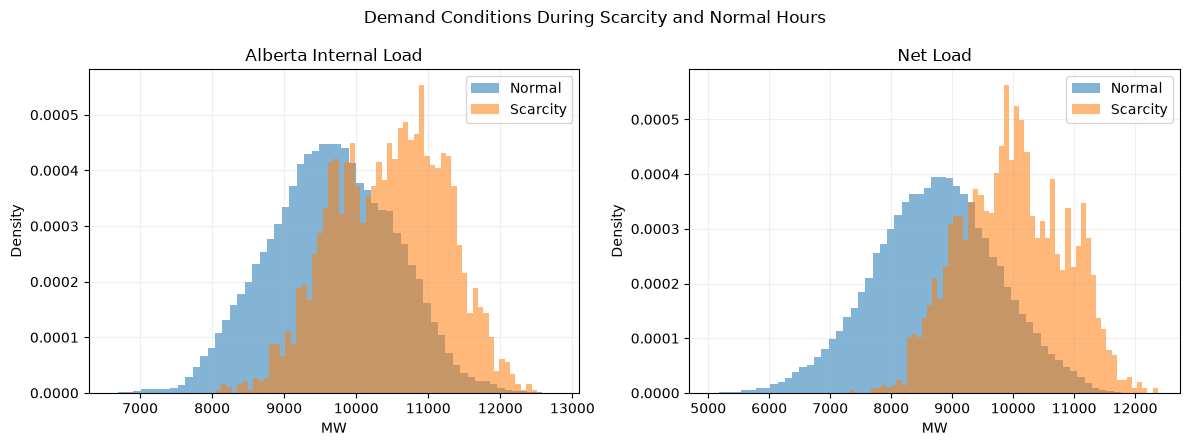

In [13]:
# ---------------------------------------------------------------------
# Plot load and net-load distributions
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1, 
    2, 
    figsize = (12, 4.5),
)

distribution_features = {
    'Alberta Internal Load': master['ail_mw'],
    'Net Load': scarcity_features['net_load_mw'],
}

for axis, (label, values) in zip(
    axes, distribution_features.items(),
):
    axis.hist(
        values.loc[~primary_event].dropna(),
        bins = 60, 
        density = True, 
        alpha = 0.55, 
        label ='Normal',
    )

    axis.hist(
        values.loc[primary_event].dropna(),
        bins = 60, 
        density = True, 
        alpha = 0.55, 
        label = 'Scarcity',
    )

    axis.set_title(label)
    axis.set_xlabel('MW')
    axis.set_ylabel('Density')
    axis.grid(alpha = 0.20)
    axis.legend()

fig.suptitle('Demand Conditions During Scarcity and Normal Hours')

plt.tight_layout()
plt.show()

#### Operating Conditions During Scarcity

Scarcity hours occur under distinctly tighter system conditions. Alberta Internal Load averages approximately 804 MW higher during scarcity, an increase of 8.3%, while net load rises by roughly 1,265 MW, or 14.5%. The larger net-load difference reflects both stronger demand and reduced renewable output. 

Variable renewable generation averages only 469 MW during scarcity hours, approximately 50% below its normal-hour average. Together, these results show that scarcity is associated with elevated demand, weaker renewable generation, and a substantially greater requirement for dispatchable supply. These relationships are descriptive and do not, by themselves, establish causality.

### 3.2 Net-Load Deciles and Annual Scarcity Lift

Net load is ranked separately within each year. This controls for demand growth and renewable expansion over the study period.

Scarcity lift is calculated as:

Scarcity lift = scarcity rate in year-decile cell / annual scarcity base rate

A stable net-load relationship should produce consistently low lift in the lower deciles and high lift in the upper deciles across multiple years.

In [14]:
# ---------------------------------------------------------------------
# Reusable year-by-decile summary
# ---------------------------------------------------------------------

def build_year_decile_summary(
    values,
    event,
):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "value": values,
        "event": event,
    }).dropna()

    frame["decile"] = (
        frame
        .groupby("year_alberta")["value"]
        .transform(
            lambda series: percentile_to_decile(
                series.rank(
                    method="average",
                    pct=True,
                )
            )
        )
    )

    annual_base_rate = (
        frame
        .groupby("year_alberta")["event"]
        .mean()
        .rename("annual_base_rate")
    )

    summary = (
        frame
        .groupby(
            ["year_alberta", "decile"],
            observed=True,
        )
        .agg(
            hours=("event", "size"),
            scarcity_rate=("event", "mean"),
            average_value=("value", "mean"),
        )
        .reset_index()
        .merge(
            annual_base_rate,
            on="year_alberta",
            how="left",
        )
    )

    summary["scarcity_lift"] = (
        summary["scarcity_rate"]
        / summary["annual_base_rate"].replace(
            0,
            np.nan,
        )
    )

    return summary

def plot_year_decile_heatmap(
    summary,
    title,
    minimum_hours=100,
):
    lift = summary.pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )

    counts = summary.pivot(
        index="year_alberta",
        columns="decile",
        values="hours",
    )

    displayed_lift = lift.where(
        counts.ge(minimum_hours)
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    image = ax.imshow(
        displayed_lift,
        aspect="auto",
        cmap="RdYlBu_r",
        vmin=0,
    )

    ax.set_xticks(range(len(displayed_lift.columns)))
    ax.set_xticklabels(displayed_lift.columns)

    ax.set_yticks(range(len(displayed_lift.index)))
    ax.set_yticklabels(displayed_lift.index)

    ax.set_xlabel(
        "Within-year decile "
        "(0 = lowest, 9 = highest)"
    )
    ax.set_ylabel("Alberta year")
    ax.set_title(title)

    fig.colorbar(
        image,
        ax=ax,
        label="Scarcity lift over annual base rate",
    )

    plt.tight_layout()
    plt.show()

    return counts

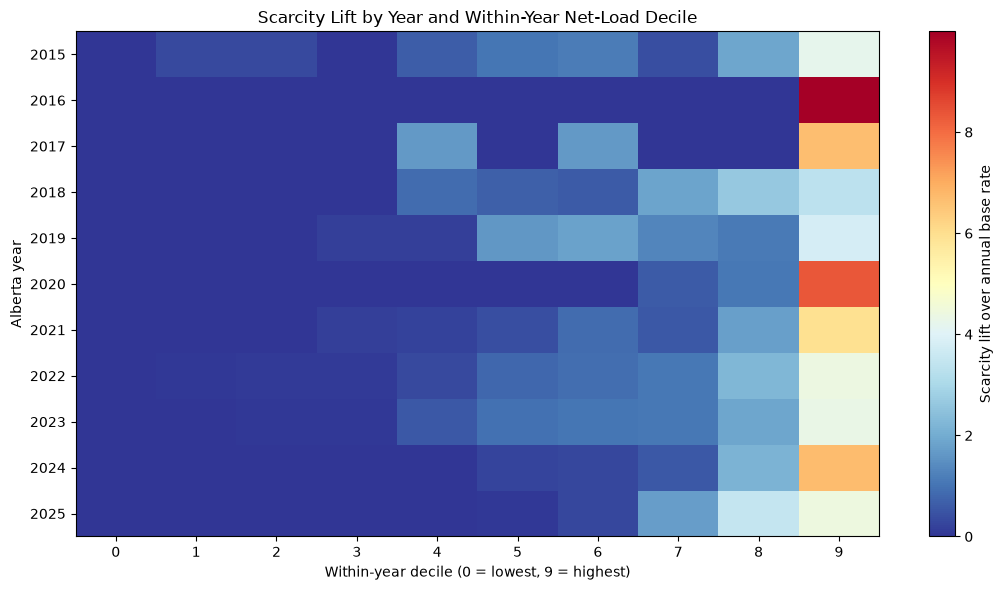

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.0,0.32,0.32,0.00,0.63,1.05,1.16,0.42,1.89,4.21
2016,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.99
2017,0.0,0.00,0.00,0.00,1.67,0.00,1.67,0.00,0.00,6.66
2018,0.0,0.00,0.00,0.00,0.88,0.69,0.59,1.86,2.65,3.33
2019,0.0,0.00,0.00,0.17,0.17,1.64,1.81,1.29,1.12,3.79
2020,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.59,1.08,8.33
2021,0.0,0.00,0.03,0.16,0.23,0.42,0.87,0.55,1.77,5.96
2022,0.0,0.04,0.09,0.11,0.34,0.79,0.94,1.06,2.26,4.37
2023,0.0,0.02,0.05,0.05,0.58,0.97,1.04,1.09,1.88,4.32


In [15]:
# ---------------------------------------------------------------------
# Net-load year-by-decile stability
# ---------------------------------------------------------------------

net_load_year_deciles = build_year_decile_summary(
    scarcity_features['net_load_mw'],
    primary_event,
)

net_load_decile_counts = plot_year_decile_heatmap(
    net_load_year_deciles,
    title = (
        'Scarcity Lift by Year and '
        'Within-Year Net-Load Decile' 
    ),
)

net_load_decile_values = (
    net_load_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(net_load_decile_values.round(2))

#### Net-Load Deciles and Annual Scarcity Lift

Scarcity risk is consistently concentrated in the highest within-year net-load deciles. The lowest decile records no scarcity events in any year, while the tenth decile produces the largest scarcity lift throughout the sample. This relationship is especially pronounced in 2024 and 2025, when lift begins rising sharply in the upper three deciles.

The pattern is broadly stable but not perfectly monotonic, particularly in years containing few scarcity events. Large tenth-decile lifts in 2016, 2017, and 2020 should therefore be interpreted cautiously: they show that the limited events were highly concentrated at extreme net load, not necessarily that those years had high absolute scarcity risk. Overall, extreme net load appears to be a persistent indicator of scarcity across different market regimes.

### 3.3 Net load across structural regimes

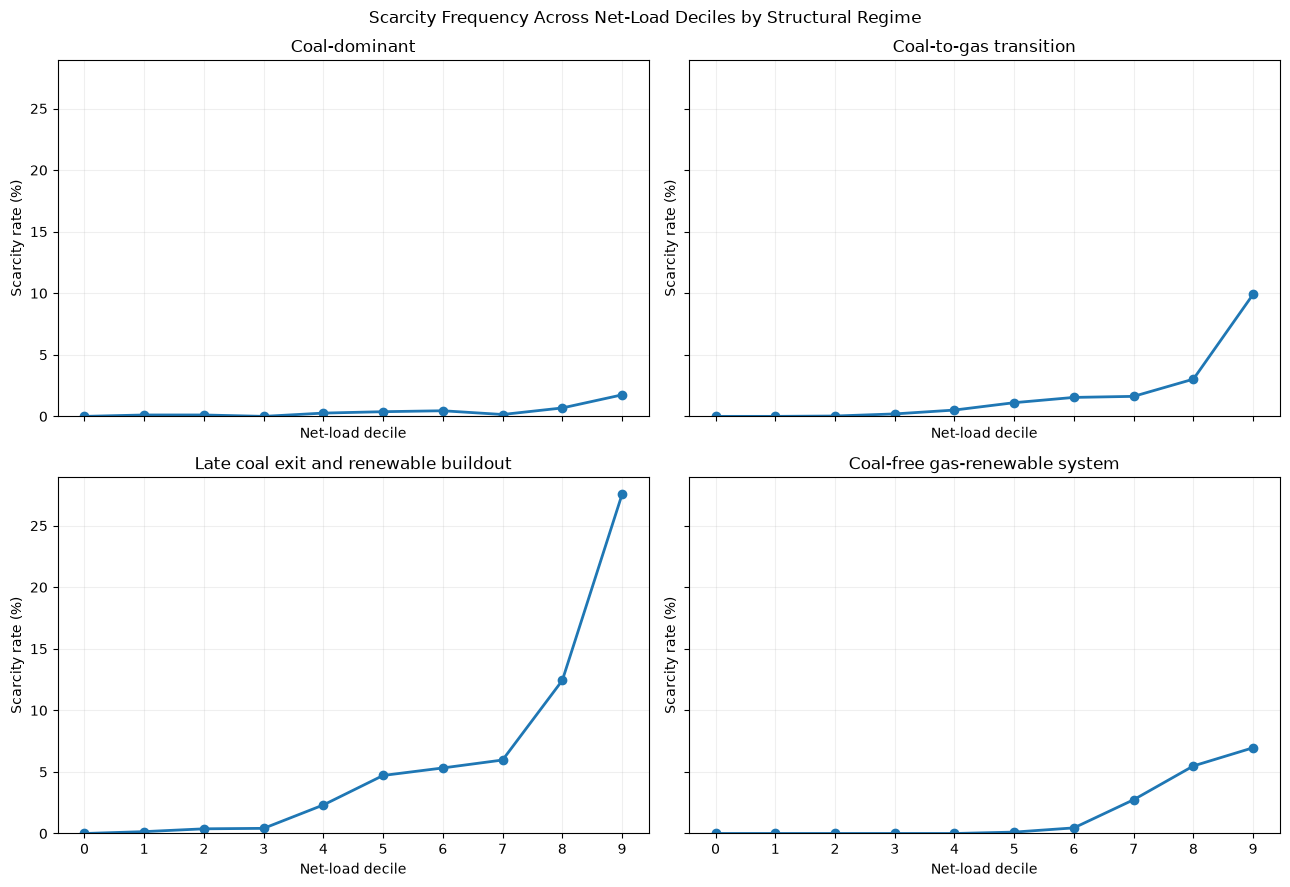

In [16]:
# ---------------------------------------------------------------------
# Compare net-load deciles across structural regimes
# ---------------------------------------------------------------------

net_load_regime_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "net_load_decile":
            scarcity_features["net_load_decile"],
        "scarcity_event": primary_event,
    })
    .dropna()
    .groupby(
        [
            "structural_regime",
            "net_load_decile",
        ],
        observed=True,
    )
    .agg(
        hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True,
    sharey=True,
)

maximum_rate = (
    net_load_regime_summary["scarcity_rate"].max()
    * 100
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = net_load_regime_summary[
        net_load_regime_summary[
            "structural_regime"
        ].eq(regime)
    ]

    axis.plot(
        plot_data["net_load_decile"],
        plot_data["scarcity_rate"] * 100,
        marker="o",
        linewidth=2,
    )

    axis.set_title(regime)
    axis.set_xticks(range(10))
    axis.set_ylim(0, maximum_rate * 1.05)
    axis.set_xlabel("Net-load decile")
    axis.set_ylabel("Scarcity rate (%)")
    axis.grid(alpha=0.20)

fig.suptitle(
    "Scarcity Frequency Across Net-Load Deciles "
    "by Structural Regime"
)

plt.tight_layout()
plt.show()

### 3.4 Net-Load Changes at Scarcity Onset

Net-load changes over one, six, and 24 hours are examined at the onset of each scarcity episode.

This is a descriptive event-onset analysis, not an exhaustive lag-selection exercise. Formal temporal-feature selection belongs in Notebook 5 and the forecasting notebooks.

In [17]:
# ---------------------------------------------------------------------
# Compare net-load changes across scarcity states
# ---------------------------------------------------------------------

event_onset = (
    primary_event
    & ~primary_event.shift(fill_value=False)
)

continuing_scarcity = (
    primary_event
    & ~event_onset
)

scarcity_state = pd.Series(
    np.select(
        [
            event_onset,
            continuing_scarcity,
        ],
        [
            "Event onset",
            "Continuing scarcity",
        ],
        default="Non-scarcity",
    ),
    index=master.index,
    name="scarcity_state",
)

net_load_ramp_rows = []

for horizon in [1, 6, 24]:
    net_load_change = (
        scarcity_features["net_load_mw"]
        - scarcity_features["net_load_mw"].shift(horizon)
    )

    ramp_frame = pd.DataFrame({
        "scarcity_state": scarcity_state,
        "net_load_change_mw": net_load_change,
    }).dropna()

    horizon_summary = (
        ramp_frame
        .groupby(
            "scarcity_state",
            observed=True,
        )
        .agg(
            observations=(
                "net_load_change_mw",
                "size",
            ),
            mean_change_mw=(
                "net_load_change_mw",
                "mean",
            ),
            median_change_mw=(
                "net_load_change_mw",
                "median",
            ),
            change_25th_percentile_mw=(
                "net_load_change_mw",
                lambda series: series.quantile(0.25),
            ),
            change_75th_percentile_mw=(
                "net_load_change_mw",
                lambda series: series.quantile(0.75),
            ),
        )
        .reset_index()
    )

    horizon_summary["horizon_hours"] = horizon
    net_load_ramp_rows.append(horizon_summary)

net_load_onset_ramps = (
    pd.concat(
        net_load_ramp_rows,
        ignore_index=True,
    )
    [
        [
            "horizon_hours",
            "scarcity_state",
            "observations",
            "mean_change_mw",
            "median_change_mw",
            "change_25th_percentile_mw",
            "change_75th_percentile_mw",
        ]
    ]
)

state_order = [
    "Non-scarcity",
    "Event onset",
    "Continuing scarcity",
]

net_load_onset_ramps["scarcity_state"] = pd.Categorical(
    net_load_onset_ramps["scarcity_state"],
    categories=state_order,
    ordered=True,
)

net_load_onset_ramps = (
    net_load_onset_ramps
    .sort_values(
        [
            "horizon_hours",
            "scarcity_state",
        ]
    )
    .reset_index(drop=True)
)

display(net_load_onset_ramps.round(2))

,horizon_hours,scarcity_state,observations,mean_change_mw,median_change_mw,change_25th_percentile_mw,change_75th_percentile_mw
0,1,Non-scarcity,93994,-1.29,-6.85,-128.24,113.90
1,1,Event onset,758,117.21,105.06,4.34,217.17
2,1,Continuing scarcity,1672,20.20,18.00,-81.54,109.99
3,6,Non-scarcity,93989,-14.04,-6.60,-613.51,573.16
4,6,Event onset,758,629.88,585.11,239.18,991.09
5,6,Continuing scarcity,1672,506.78,485.13,194.44,820.53
6,24,Non-scarcity,93971,-9.85,-5.44,-412.07,389.16
7,24,Event onset,758,426.98,285.78,16.25,752.22
8,24,Continuing scarcity,1672,363.26,263.49,-2.84,633.34


#### Net-Load Changes at Scarcity Onset

Scarcity onset is associated with substantial increases in net load. During the first hour of a scarcity episode, net load increased by an average of approximately 117 MW over the preceding hour, 630 MW over six hours, and 427 MW over 24 hours. Median changes were similarly positive—105 MW, 585 MW, and 286 MW, respectively—indicating that the pattern is not driven solely by a small number of extreme events.

The largest separation occurs over the six-hour horizon. The middle 50% of onset observations experienced six-hour net-load increases ranging from approximately 239 MW to 991 MW. By comparison, non-scarcity hours had an average six-hour change of −14 MW and a median change of −7 MW.

Net load also remained elevated during continuing scarcity hours. Average changes during ongoing events were approximately 20 MW over one hour, 507 MW over six hours, and 363 MW over 24 hours. This suggests that scarcity episodes frequently begin during sustained multi-hour increases in net load rather than isolated one-hour movements.

Overall, the results show that scarcity onset is commonly preceded by a pronounced buildup in net load, particularly over the preceding six hours. However, these changes include net load observed in the scarcity hour itself. They should therefore be interpreted as descriptive event-onset patterns rather than as confirmed advance forecasting signals.

### Section 3 Summary

Net load separates scarcity from normal operation more clearly than gross load. Alberta Internal Load is approximately 8.3% higher during scarcity, whereas net load is approximately 14.5% higher. The larger net-load difference reflects the joint effect of stronger demand and weaker renewable generation: variable renewable output is approximately 49.6% lower during scarcity hours. Net load therefore captures the demand that must be met by dispatchable generation, hydro, and imports more effectively than gross load alone.

The relationship is concentrated primarily in the upper tail rather than following a uniform linear gradient. Scarcity is effectively absent from the lowest within-year net-load decile and becomes progressively more frequent as net load approaches its annual maximum. Net load’s highest-risk tail produces a scarcity lift of approximately 4.45, while its overall ROC-AUC of 0.828 and precision-recall AUC of 0.148 indicate substantially stronger separation than the 2.5% scarcity prevalence alone would imply.

This upper-tail relationship persists across years and structural regimes. The highest net-load decile produces the greatest annual scarcity lift throughout the sample, although the magnitude should be interpreted cautiously in years containing few scarcity events. Regime-specific ROC-AUC ranges from 0.762 in the coal-dominant period to 0.880 in the coal-free gas-renewable system, showing that net load remains informative despite major changes in Alberta’s generation mix.

Scarcity onset is also associated with a pronounced buildup in net load. At the first hour of an episode, net load is approximately 117 MW higher than one hour earlier, 630 MW higher than six hours earlier, and 427 MW higher than 24 hours earlier. Net load remains elevated during continuing scarcity, indicating that episodes frequently develop during sustained multi-hour pressure rather than isolated hourly movements.

Overall, net load provides a stable and economically interpretable measure of demand pressure. It should be retained as a primary candidate for later forecasting analysis, but actual contemporaneous net load is not itself forecast-ready. An ex-ante version must be constructed from load, wind, and solar forecasts available before the target hour.

## 4. Supply Availability, Outages, and Interties

### 4.1 Thermal Availability and Headroom

Thermal availability measures the reported coal- and gas-fired supply available during each hour. Thermal headroom measures reported thermal availability minus actual thermal generation.

Thermal headroom is preferable to subtracting total load from thermal availability because Alberta load is also served by hydro, renewable generation, imports, and other resources.

In [18]:
# ---------------------------------------------------------------------
# Compare thermal conditions
# ---------------------------------------------------------------------

thermal_comparison = compare_event_means(
    {
        "Reported thermal availability (MW)":
            scarcity_features[
                "reported_thermal_available_mw"
            ],

        "Reported thermal generation (MW)":
            scarcity_features[
                "reported_thermal_generation_mw"
            ],

        "Thermal headroom (MW)":
            scarcity_features[
                "thermal_headroom_mw"
            ],

        "Thermal utilization (%)":
            scarcity_features[
                "thermal_utilization_pct"
            ],
    },
    primary_event,
)

display(thermal_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported thermal availability (MW),9752.02,9253.68,9728.00,9281.00,-498.34,-5.11
Reported thermal generation (MW),5896.34,6548.21,5891.51,6514.43,651.86,11.06
Thermal headroom (MW),3855.68,2705.48,3777.41,2675.35,-1150.20,-29.83
Thermal utilization (%),60.49,70.74,60.97,70.76,10.25,16.95


In [19]:
# ---------------------------------------------------------------------
# Audit technology-level thermal availability
# ---------------------------------------------------------------------

technology_availability_rows = []

for technology in THERMAL_TECHNOLOGIES:
    column = f"{technology}_system_available"
    reported = master[column].notna()

    technology_availability_rows.append({
        "technology": technology,
        "coverage_pct": reported.mean() * 100,

        "first_reported": master.loc[
            reported,
            "timestamp_alberta",
        ].min(),

        "last_reported": master.loc[
            reported,
            "timestamp_alberta",
        ].max(),

        "normal_mean_mw": master.loc[
            reported & ~primary_event,
            column,
        ].mean(),

        "scarcity_mean_mw": master.loc[
            reported & primary_event,
            column,
        ].mean(),
    })

technology_availability = pd.DataFrame(
    technology_availability_rows
)

technology_availability["difference_mw"] = (
    technology_availability["scarcity_mean_mw"]
    - technology_availability["normal_mean_mw"]
)

technology_availability["pct_difference"] = (
    technology_availability["difference_mw"]
    / technology_availability[
        "normal_mean_mw"
    ].replace(0, np.nan)
    * 100
)

# Round only numeric columns so timestamp columns remain unchanged.
technology_availability_display = (
    technology_availability.copy()
)

numeric_columns = (
    technology_availability_display
    .select_dtypes(include="number")
    .columns
)

technology_availability_display[numeric_columns] = (
    technology_availability_display[
        numeric_columns
    ].round(2)
)

display(technology_availability_display)

,technology,coverage_pct,first_reported,last_reported,normal_mean_mw,scarcity_mean_mw,difference_mw,pct_difference
0,coal,86.34,2015-01-01 00:00:00-07:00,2024-06-30 23:00:00-06:00,3507.37,1723.32,-1784.05,-50.87
1,cogeneration,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,3093.79,3197.85,104.06,3.36
2,combined_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,1686.78,1678.51,-8.27,-0.49
3,dual_fuel,51.77,2018-03-05 00:00:00-07:00,2024-07-11 23:00:00-06:00,447.83,453.02,5.20,1.16
4,gas_fired_steam,44.67,2021-02-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,2204.66,2168.90,-35.76,-1.62
5,simple_cycle,100.00,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,753.52,729.55,-23.97,-3.18


In [20]:
# ---------------------------------------------------------------------
# Audit the internal dual-fuel reporting gap
# ---------------------------------------------------------------------

dual_fuel_gap = scarcity_features[
    "dual_fuel_reporting_gap"
]

dual_fuel_gap_audit = pd.DataFrame([
    {
        "affected_hours": int(
            dual_fuel_gap.sum()
        ),
        "first_affected_hour": master.loc[
            dual_fuel_gap,
            "timestamp_alberta",
        ].min(),
        "last_affected_hour": master.loc[
            dual_fuel_gap,
            "timestamp_alberta",
        ].max(),
        "availability_missing_hours": int(
            (
                dual_fuel_gap
                & master[
                    "dual_fuel_system_available"
                ].isna()
            ).sum()
        ),
        "generation_missing_hours": int(
            (
                dual_fuel_gap
                & master[
                    "dual_fuel_system_generation"
                ].isna()
            ).sum()
        ),
        "scarcity_hours_during_gap": int(
            (
                dual_fuel_gap
                & primary_event
            ).sum()
        ),
    }
])

display(dual_fuel_gap_audit)

,affected_hours,first_affected_hour,last_affected_hour,availability_missing_hours,generation_missing_hours,scarcity_hours_during_gap
0,5783,2022-03-08 00:00:00-07:00,2022-11-03 23:00:00-06:00,5783,5783,457


#### Thermal Availability and Headroom

Scarcity hours are characterized by a substantially tighter thermal supply position. Reported thermal availability averages approximately 498 MW lower, while thermal generation is about 652 MW higher. Together, these changes reduce average thermal headroom by roughly 1,150 MW, or 29.8%. Thermal utilization consequently rises from 60.5% during normal hours to 70.7% during scarcity—an increase of 10.25 percentage points.

The technology-level availability results require more cautious interpretation because reporting coverage and fleet composition change over time. In particular, coal availability is much lower during scarcity largely because scarcity became more frequent as Alberta’s coal fleet declined. Availability for cogeneration, combined-cycle, dual-fuel, gas-fired steam, and simple-cycle resources differs relatively little between normal and scarcity hours.

Overall, scarcity appears to reflect greater use of a smaller reported thermal availability stack rather than widespread reductions in the availability of every thermal technology. Regime-controlled comparisons are necessary to separate immediate operational tightness from Alberta’s longer-term generation transition.

Dual-fuel availability and generation contain an internal reporting gap from March 8 through November 4, 2022. During this interval, the reported thermal totals continue to include the other thermal technologies, but dual-fuel availability and generation are omitted because the aggregation retains the available technology-level observations rather than imputing missing values.

The affected hours are explicitly flagged in scarcity_features. No dual-fuel values are fabricated. A sensitivity test later in the notebook evaluates whether excluding the reporting gap changes the estimated scarcity separation of thermal headroom.

### 4.2 Absolute and Relative Outage Burden

Absolute outages measure unavailable generation in MW. Relative outage burden divides total outages by reported system capacity. 

The relative measure helps distinguish a large outage in a smaller historical fleet from the same outage magnitude after the fleet expanded. 

In [21]:
# ---------------------------------------------------------------------
# Compare outage conditions
# ---------------------------------------------------------------------

outage_comparison = compare_event_means(
    {
        "Total outages (MW)":
            master["total_outage_mw"],

        "Thermal outages (MW)":
            master["thermal_outage_mw"],

        "Renewable outages (MW)":
            master["renewable_outage_mw"],

        "Simple-cycle outages (MW)":
            master["simple_cycle_outage"],

        "Combined-cycle outages (MW)":
            master["combined_cycle_outage"],

        "Cogeneration outages (MW)":
            master["cogeneration_outage"],

        "Outage share of capacity (%)":
            scarcity_features[
                "outage_share_of_capacity_pct"
            ],
    },
    primary_event,
)

display(
    outage_comparison
    .sort_values(
        'mean_pct_difference',
        ascending = False,
    )
    .round(2)
)

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Renewable outages (MW),465.83,749.97,319.30,628.30,284.14,61.00
Simple-cycle outages (MW),253.74,373.53,211.40,347.40,119.79,47.21
Total outages (MW),3542.30,3883.47,3473.30,3810.40,341.17,9.63
Cogeneration outages (MW),1411.76,1533.68,1378.00,1600.35,121.92,8.64
Outage share of capacity (%),20.79,22.17,20.69,22.06,1.37,6.61
Thermal outages (MW),3072.37,3125.08,3049.10,3095.10,52.71,1.72
Combined-cycle outages (MW),467.52,435.66,284.00,259.00,-31.86,-6.81


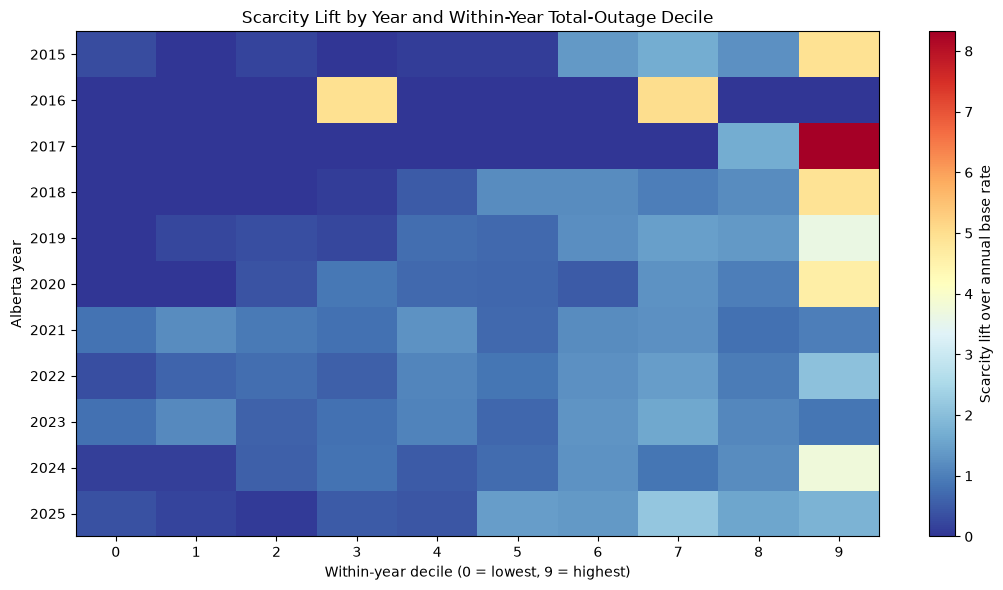

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.32,0.00,0.21,0.00,0.11,0.11,1.37,1.69,1.27,4.94
2016,0.00,0.00,0.00,4.96,0.00,0.00,0.00,5.01,0.00,0.00
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.67,8.32
2018,0.00,0.00,0.00,0.10,0.49,1.18,1.18,0.98,1.17,4.90
2019,0.00,0.26,0.34,0.26,0.78,0.69,1.21,1.47,1.38,3.62
2020,0.00,0.00,0.39,0.88,0.69,0.68,0.49,1.27,0.98,4.60
2021,0.84,1.19,0.94,0.80,1.27,0.71,1.20,1.25,0.81,1.00
2022,0.36,0.62,0.75,0.58,1.08,0.86,1.27,1.45,0.96,2.07
2023,0.79,1.14,0.61,0.81,1.07,0.66,1.32,1.61,1.11,0.87


In [22]:
# ---------------------------------------------------------------------
# Test annual stability of total-outage burden
# ---------------------------------------------------------------------

outage_year_deciles = build_year_decile_summary(
    master['total_outage_mw'],
    primary_event,
)

outage_decile_counts = plot_year_decile_heatmap(
    outage_year_deciles,
    title = (
        'Scarcity Lift by Year and '
        'Within-Year Total-Outage Decile'
    ),
)

outage_year_decile_values = (
    outage_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(outage_year_decile_values.round(2))

#### Absolute and Relative Outage Burden

Scarcity hours are associated with higher outage levels, although the relationship varies considerably by technology. Renewable outages show the largest relative difference, averaging 61% more during scarcity, followed by simple-cycle outages at 47%. Total outages increase by approximately 341 MW, or 9.6%, while the outage share of reported system capacity rises by 1.37 percentage points.

Aggregate thermal outages are only 1.7% higher during scarcity, indicating that the relationship is not explained by uniformly elevated thermal unavailability. Combined-cycle outages are actually lower during scarcity hours, potentially reflecting greater availability or operational commitment from these units when the system is tight. These comparisons are descriptive and may also reflect differences across seasons, generation regimes, and technology-reporting periods.

### 4.3 Imports and Intertie Capability

Observed imports measure the external supply that actually entered Alberta. Available-transfer capability measures the reported ability of the interties to support additional imports.

Actual imports and import capability should not be treated as interchangeable:

- imports may rise in response to domestic scarcity;
- low capability can restrict the amount of external support available; and
- actual flow data may not be known at the intended forecasting origin.

No import-utilization ratio is constructed because the aggregated flow and capability fields require careful alignment before such a ratio can be given a physical interpretation.

In [23]:
# ---------------------------------------------------------------------
# Audit intertie flow and capability coverage
# ---------------------------------------------------------------------

INTERTIE_COLUMNS = [
    "total_imports_mw",
    "total_exports_mw",
    "net_imports_mw",
    "atc_sk_import",
    "atc_wecc_import",
    "ttc_sk_import",
    "ttc_wecc_import",
]

intertie_reporting = pd.DataFrame(
    {
        "missing_hours":
            master[INTERTIE_COLUMNS].isna().sum(),

        "coverage_pct":
            master[INTERTIE_COLUMNS].notna().mean()
            * 100,

        "mean":
            master[INTERTIE_COLUMNS].mean(),

        "minimum":
            master[INTERTIE_COLUMNS].min(),

        "maximum":
            master[INTERTIE_COLUMNS].max(),
    }
)

display(intertie_reporting.round(2))

,missing_hours,coverage_pct,mean,minimum,maximum
total_imports_mw,3666,96.2,262.94,0.0,1154.0
total_exports_mw,3666,96.2,131.52,0.0,1232.0
net_imports_mw,3666,96.2,131.42,-1082.0,1154.0
atc_sk_import,0,100.0,119.36,0.0,153.0
atc_wecc_import,0,100.0,587.50,0.0,1110.0
ttc_sk_import,0,100.0,123.68,0.0,153.0
ttc_wecc_import,0,100.0,1048.79,0.0,1110.0


In [24]:
# ---------------------------------------------------------------------
# Compare intertie conditions
# ---------------------------------------------------------------------

intertie_comparison = compare_event_means(
    {
        "Total imports (MW)":
            master["total_imports_mw"],

        "Total exports (MW)":
            master["total_exports_mw"],

        "Net imports (MW)":
            master["net_imports_mw"],

        "Net imports as share of load (%)":
            scarcity_features[
                "net_import_share_of_load_pct"
            ],

        "Reported import ATC (MW)":
            scarcity_features["import_atc_mw"],

        "Reported import TTC (MW)":
            scarcity_features["import_ttc_mw"],
    },
    primary_event,
)

display(intertie_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Total imports (MW),256.39,515.71,153.0,527.00,259.32,101.14
Total exports (MW),133.74,45.69,0.0,0.00,-88.06,-65.84
Net imports (MW),122.64,470.02,100.0,511.00,347.38,283.24
Net imports as share of load (%),1.30,4.49,1.0,5.03,3.20,246.57
Reported import ATC (MW),709.18,617.28,721.0,657.50,-91.90,-12.96
Reported import TTC (MW),1173.01,1151.48,1263.0,1200.00,-21.53,-1.84


#### Imports and Intertie Capability

Observed intertie flows are available for 96.2% of the study period, while reported Saskatchewan and WECC transfer capabilities have complete coverage. Missing flow observations are retained as missing and are not interpreted as zero imports or exports.

Alberta relies much more heavily on imported electricity during scarcity. Total imports average approximately 516 MW—more than twice their normal-hour level—while exports fall by about 88 MW. Net imports consequently rise from 123 MW during normal hours to 470 MW during scarcity, increasing from 1.3% to 4.5% of Alberta load.

At the same time, reported import ATC averages approximately 92 MW lower during scarcity, a decline of 13%, whereas TTC is only 2% lower. This suggests that scarcity is associated with greater import dependence despite less immediately available transfer capability. The results do not establish whether imports mitigate scarcity, respond to high Alberta prices, or reflect a common tight-system condition; that distinction requires temporal and joint-condition analysis.

### Section 4 Summary

The supply-side results distinguish three related scarcity mechanisms: reduced absolute availability, intensive use of available thermal generation, and constrained access to external support.

First, scarcity is associated with lower reported thermal availability. Available thermal supply averages approximately 9,254 MW during scarcity, about 498 MW or 5.1% below its normal-hour average. This reduction is meaningful, but it is not the only source of pressure. Technology-level comparisons are influenced by the changing generation mix and reporting boundaries, so differences in individual technologies should not be interpreted as isolated causal effects.

Second, the available thermal fleet is used much more intensively during scarcity. Reported thermal generation is approximately 652 MW, or 11.1%, higher than during normal hours. The combination of lower availability and higher generation compresses average thermal headroom by approximately 1,150 MW, a reduction of nearly 30%. Thermal utilization consequently rises from approximately 60.5% during normal operation to 70.7% during scarcity. These results indicate that scarcity is associated not merely with fewer available resources, but with substantially less unused flexibility among the thermal resources that remain available.

Outages contribute to this pressure unevenly. Total outages are approximately 341 MW, or 9.6%, higher during scarcity, while renewable and simple-cycle outages display the largest relative increases. Aggregate thermal outages are only 1.7% higher, and combined-cycle outages are lower during scarcity. Outages should therefore not be interpreted as a uniform standalone scarcity mechanism. Their importance depends on which resources are unavailable and whether the system is already experiencing elevated net load or compressed available margin.

Third, Alberta relies more heavily on external support as domestic conditions tighten. Net imports average approximately 470 MW during scarcity, compared with 123 MW during normal hours. At the same time, reported import ATC is approximately 13% lower, indicating greater import dependence despite reduced immediately available transfer capability. Observed imports and import capability therefore represent different mechanisms: actual flows respond to Alberta’s system pressure and prices, while available-transfer capability constrains how much additional support the interties can provide.

Overall, scarcity reflects the interaction of reduced availability, intensive thermal-fleet use, selective outage pressure, and reliance on intertie support. Thermal headroom provides the clearest summary of domestic operational tightness, while outages and import capability are most informative when interpreted conditionally. Because availability, dispatch, outages, and observed imports are contemporaneous measurements, their use in forecasting requires forecast-vintage or explicitly predicted equivalents.

## 5. Available System Margin

### 5.1 Capacity, availability, and system headroom

This is the notebook’s central section.

Four related measures are compared:

- reported capacity margin;
- domestic available margin;
- intertie-supported margin; and
- reported supply headroom.

Reported capacity margin is structural. Domestic available margin reflects contemporaneous reported availability relative to load. Intertie-supported margin adds observed net imports. Reported supply headroom measures available system supply that was not being generated.

None of these measures should be labelled official operating reserve.

In [25]:
# ---------------------------------------------------------------------
# Compare capacity and availability-based margins
# ---------------------------------------------------------------------

margin_comparison = compare_event_means(
    {
        "Reported capacity margin (MW)":
            scarcity_features[
                "reported_capacity_margin_mw"
            ],

        "Domestic available margin (MW)":
            scarcity_features[
                "domestic_available_margin_mw"
            ],

        "Intertie-supported margin (MW)":
            scarcity_features[
                "intertie_supported_margin_mw"
            ],

        "Reported supply headroom (MW)":
            scarcity_features[
                "reported_supply_headroom_mw"
            ],

        "Available margin as share of load (%)":
            scarcity_features[
                "available_margin_pct_of_load"
            ],
    },
    primary_event,
)

display(margin_comparison.round(2))

,normal_mean,scarcity_mean,normal_median,scarcity_median,mean_difference,mean_pct_difference
Reported capacity margin (MW),7454.11,7086.33,6671.20,6749.08,-367.78,-4.93
Domestic available margin (MW),3763.77,3083.78,3169.00,2913.00,-679.99,-18.07
Intertie-supported margin (MW),3729.63,3410.65,3295.00,3317.00,-318.98,-8.55
Reported supply headroom (MW),6317.34,6122.93,5743.98,6044.46,-194.41,-3.08
Available margin as share of load (%),39.26,29.77,34.11,27.94,-9.48,-24.16


#### Capacity, availability, and system headroom

Scarcity hours are associated with tighter operational margins, although the magnitude depends on how available supply is measured. Reported capacity margin is approximately 368 MW lower during scarcity, a decline of only 4.9%. In contrast, domestic available margin falls by roughly 680 MW, or 18.1%, and declines from 39.3% to 29.8% of Alberta load.

Accounting for net imports reduces the difference: intertie-supported margin is approximately 319 MW lower during scarcity, compared with the 680 MW reduction in domestic available margin. This indicates that increased imports partially offset tighter domestic supply conditions, although they do not eliminate the margin reduction.

Reported supply headroom changes comparatively little, declining by about 3% on average, while its median is slightly higher during scarcity. Overall, operational availability relative to load appears more closely associated with scarcity than reported fleet capacity alone, reinforcing the distinction between the size of the generation fleet and the supply actually available during stressed hours.

### 5.2 Available-Margin Deciles and Annual Stability

Domestic available margin is ranked within each year. Decile 0 contains the tightest 10% of available-margin hours, while decile 9 contains the loosest 10%.

Using within-year deciles prevents structural capacity growth from obscuring the operating relationship.

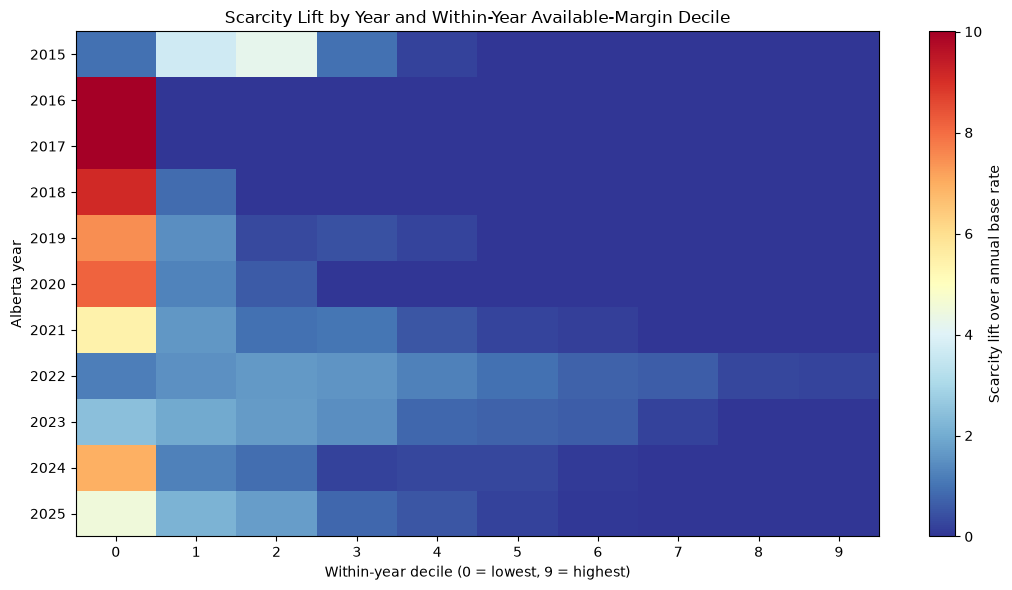

decile,0,1,2,3,4,5,6,7,8,9
year_alberta,,,,,,,,,,
2015,0.95,3.68,4.21,0.95,0.21,0.00,0.00,0.00,0.00,0.00
2016,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018,9.13,0.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2019,7.50,1.47,0.35,0.43,0.26,0.00,0.00,0.00,0.00,0.00
2020,8.13,1.27,0.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2021,5.43,1.61,0.97,1.03,0.52,0.26,0.16,0.03,0.00,0.00
2022,1.18,1.50,1.64,1.58,1.24,0.98,0.73,0.63,0.29,0.24
2023,2.43,1.97,1.71,1.46,0.80,0.71,0.66,0.23,0.02,0.02


In [26]:
# ---------------------------------------------------------------------
# Available-margin year-by-decile stability
# ---------------------------------------------------------------------

available_margin_year_deciles = (
    build_year_decile_summary(
        scarcity_features[
            "domestic_available_margin_mw"
        ],
        primary_event,
    )
)

available_margin_decile_counts = (
    plot_year_decile_heatmap(
        available_margin_year_deciles,
        title=(
            "Scarcity Lift by Year and "
            "Within-Year Available-Margin Decile"
        ),
    )
)

available_margin_year_decile_values = (
    available_margin_year_deciles
    .pivot(
        index="year_alberta",
        columns="decile",
        values="scarcity_lift",
    )
    .sort_index()
)

display(available_margin_year_decile_values.round(2))

#### Available-Margin Deciles and Annual Stability

Scarcity is generally concentrated in hours with the lowest domestic available margins. In most years, scarcity lift is highest in the bottom margin deciles and falls toward zero as available margin increases. During 2016–2018, 2020, and 2024, the lowest decile captures an especially large share of the year’s scarcity events.

The relationship is less concentrated during 2021–2023. In 2022, scarcity remained elevated across several middle-margin deciles, suggesting that the unusually high base rate that year cannot be explained by only the most margin-constrained hours. Fuel costs, renewable conditions, outages, imports, or other regime-specific factors may also have contributed.

Overall, low domestic available margin is a persistent scarcity indicator, but its strength varies across years. Rare-event years produce particularly large lowest-decile lifts, while high-scarcity years display a broader distribution of risk across operating conditions.

### 5.3 Available-Margin States

Four operating states are defined from each year’s domestic available-margin distribution:

- **Critical:** bottom 5%;
- **Tight:** 5th–20th percentile;
- **Balanced:** 20th–80th percentile; and
- **Loose:** top 20%.

These states describe relative operating tightness within each year rather than imposing a single MW threshold on a generation fleet that changed substantially over time.

In [27]:
# ---------------------------------------------------------------------
# Profile each available-margin state
# ---------------------------------------------------------------------

margin_state_profile = (
    pd.DataFrame({
        "margin_state":
            scarcity_features["margin_state"],

        "event_300":
            scarcity_features[
                "price_at_or_above_300"
            ],

        "event_500":
            scarcity_features[
                "price_at_or_above_500"
            ],

        "event_900":
            scarcity_features[
                "price_at_or_above_900"
            ],

        "pool_price":
            master["pool_price"],

        "ail_mw":
            master["ail_mw"],

        "net_load_mw":
            scarcity_features["net_load_mw"],

        "available_margin_mw":
            scarcity_features[
                "domestic_available_margin_mw"
            ],

        "thermal_headroom_mw":
            scarcity_features[
                "thermal_headroom_mw"
            ],

        "total_outage_mw":
            master["total_outage_mw"],

        "net_imports_mw":
            master["net_imports_mw"],
    })
    .groupby("margin_state", observed=True)
    .agg(
        hours=("event_500", "size"),
        high_price_rate=("event_300", "mean"),
        scarcity_rate=("event_500", "mean"),
        extreme_rate=("event_900", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
        price_75th_percentile=(
            "pool_price",
            lambda series: series.quantile(0.75),
        ),
        price_90th_percentile=(
            "pool_price",
            lambda series: series.quantile(0.90),
        ),
        average_load_mw=("ail_mw", "mean"),
        average_net_load_mw=("net_load_mw", "mean"),
        average_available_margin_mw=(
            "available_margin_mw",
            "mean",
        ),
        average_thermal_headroom_mw=(
            "thermal_headroom_mw",
            "mean",
        ),
        average_total_outage_mw=(
            "total_outage_mw",
            "mean",
        ),
        average_net_imports_mw=(
            "net_imports_mw",
            "mean",
        ),
    )
    .reindex(MARGIN_STATE_ORDER)
)

for column in [
    "high_price_rate",
    "scarcity_rate",
    "extreme_rate",
]:
    margin_state_profile[f"{column}_pct"] = (
        margin_state_profile[column] * 100
    )

display(margin_state_profile.round(2))

,hours,high_price_rate,scarcity_rate,extreme_rate,average_price,median_price,price_75th_percentile,price_90th_percentile,average_load_mw,average_net_load_mw,average_available_margin_mw,average_thermal_headroom_mw,average_total_outage_mw,average_net_imports_mw,high_price_rate_pct,scarcity_rate_pct,extreme_rate_pct
margin_state,,,,,,,,,,,,,,,,,
Critical,4817,0.17,0.13,0.04,167.71,52.42,131.19,631.69,10523.20,9516.49,2103.19,2905.07,4111.97,397.57,17.11,12.62,4.15
Tight,14464,0.08,0.05,0.01,96.31,39.66,73.91,215.19,10261.61,9280.67,2740.86,3278.48,3779.50,271.58,7.76,4.73,0.86
Balanced,57851,0.03,0.02,0.00,60.83,32.99,51.59,96.47,9713.44,8801.01,3742.11,3786.42,3531.03,122.38,3.40,1.89,0.17
Loose,19293,0.01,0.00,0.00,35.23,26.75,35.90,61.39,8910.47,8040.14,4924.57,4588.56,3299.01,-5.68,0.69,0.22,0.00


#### Available-Margin States

Price outcomes deteriorate sharply as domestic available margin tightens. Critical-margin hours have an average pool price of $167.71/MWh and a scarcity rate of 12.62%, compared with $35.23/MWh and 0.22% during loose-margin conditions. Extreme prices occur during 4.15% of critical hours but are effectively absent when margins are loose.

Critical conditions combine higher load and net load with lower thermal headroom, greater outages, and increased reliance on imports. Average net imports rise to approximately 398 MW during critical hours, compared with slight net exports during loose conditions. The consistent progression across margin states indicates that the within-year available-margin classification captures economically meaningful changes in system tightness.

### 5.4 Margin-State Stability Across Structural Regimes

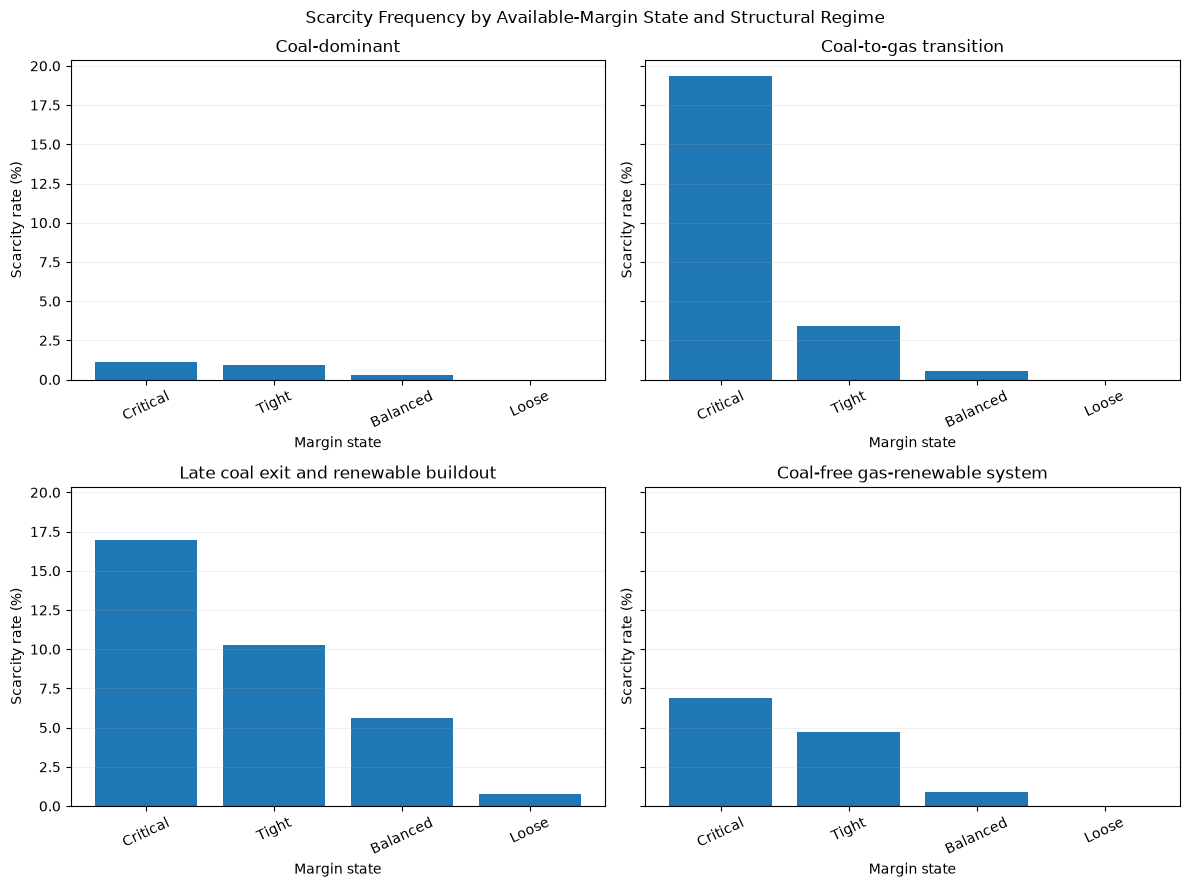

In [28]:
# ---------------------------------------------------------------------
# Compare margin states across structural regimes
# ---------------------------------------------------------------------

regime_margin_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "margin_state": scarcity_features["margin_state"],
        "scarcity_event": primary_event,
    })
    .groupby(
        [
            "structural_regime",
            "margin_state",
        ],
        observed=True,
    )
    .agg(
        hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
)

maximum_rate = (
    regime_margin_summary["scarcity_rate"].max()
    * 100
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = (
        regime_margin_summary[
            regime_margin_summary[
                "structural_regime"
            ].eq(regime)
        ]
        .set_index("margin_state")
        .reindex(MARGIN_STATE_ORDER)
    )

    axis.bar(
        plot_data.index,
        plot_data["scarcity_rate"] * 100,
    )

    axis.set_title(regime)
    axis.set_ylim(0, maximum_rate * 1.05)
    axis.set_xlabel("Margin state")
    axis.set_ylabel("Scarcity rate (%)")
    axis.tick_params(axis="x", labelbottom=True, rotation=25,)
    axis.grid(axis="y", alpha=0.20)

fig.suptitle(
    "Scarcity Frequency by Available-Margin State "
    "and Structural Regime"
)

plt.tight_layout()
plt.show()

#### Margin-State Stability Across Structural Regimes

The inverse relationship between available margin and scarcity persists across all four structural regimes: scarcity rates are highest during critical-margin hours and generally decline as margins loosen. However, the absolute level and distribution of scarcity change substantially across regimes.

Scarcity was uncommon throughout the coal-dominant period, even under critical conditions. During the coal-to-gas transition, scarcity became sharply concentrated in the critical state, where the event rate approached 20%. During the late coal-exit and renewable-buildout regime, scarcity remained elevated across critical, tight, and balanced conditions, indicating a broader period of market stress rather than risk confined exclusively to the lowest margins.

The coal-free gas-renewable system shows lower scarcity rates than the preceding regime while retaining a clear margin gradient. Because this regime currently contains only 2025, it should be treated as an initial snapshot rather than evidence of a stable long-term relationship. Overall, low available margin remains a consistent scarcity indicator, but structural market conditions strongly influence the magnitude and breadth of the associated risk.

## 6. Conditional Scarcity Drivers

### 6.1 Conditional-State Methodology

Individual variables are not expected to explain scarcity in isolation. This section tests whether their effects depend on the broader operating state.

Four interactions are examined:

- available-margin state × outage state;
- available-margin state × intertie capability;
- net-load decile × outage decile; and
- thermal-headroom decile × import-flow decile.

Every cell reports its observation count. Cells with fewer than 100 observations are suppressed from the heatmaps.

Annual lift is calculated only for year-cells containing at least 25 observations. A median annual lift is reported only when at least five years satisfy that requirement; otherwise, the pooled scarcity rate is retained without a claim of annual stability.

In [29]:
# ---------------------------------------------------------------------
# Reusable conditional-state summary and heatmap
# ---------------------------------------------------------------------

MINIMUM_CELL_HOURS = 100
MINIMUM_ANNUAL_CELL_HOURS = 25
MINIMUM_QUALIFYING_YEARS = 5


def build_conditional_summary(
    row_state,
    column_state,
    event,
    minimum_annual_cell_hours=(
        MINIMUM_ANNUAL_CELL_HOURS
    ),
    minimum_qualifying_years=(
        MINIMUM_QUALIFYING_YEARS
    ),
):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "row_state": row_state,
        "column_state": column_state,
        "event": event,
    }).dropna()

    # Pooled association across the full study period.
    overall = (
        frame
        .groupby(
            ["row_state", "column_state"],
            observed=True,
        )
        .agg(
            hours=("event", "size"),
            scarcity_rate=("event", "mean"),
        )
        .reset_index()
    )

    # Estimate each conditional cell separately by year.
    annual_cells = (
        frame
        .groupby(
            [
                "year_alberta",
                "row_state",
                "column_state",
            ],
            observed=True,
        )
        .agg(
            annual_cell_hours=("event", "size"),
            annual_cell_rate=("event", "mean"),
        )
        .reset_index()
    )

    annual_base = (
        frame
        .groupby("year_alberta")["event"]
        .mean()
        .rename("annual_base_rate")
        .reset_index()
    )

    annual_cells = annual_cells.merge(
        annual_base,
        on="year_alberta",
        how="left",
    )

    annual_cells["annual_lift"] = (
        annual_cells["annual_cell_rate"]
        / annual_cells[
            "annual_base_rate"
        ].replace(0, np.nan)
    )

    # Record how many years contain each cell before
    # imposing the annual sample-size requirement.
    years_observed = (
        annual_cells
        .groupby(
            ["row_state", "column_state"],
            observed=True,
        )
        .agg(
            years_observed=(
                "year_alberta",
                "nunique",
            ),
        )
        .reset_index()
    )

    # Exclude sparse annual cells from the stability
    # statistic. Annual lift must also be defined.
    qualifying_annual_cells = (
        annual_cells.loc[
            annual_cells[
                "annual_cell_hours"
            ].ge(minimum_annual_cell_hours)
            & annual_cells[
                "annual_lift"
            ].notna()
        ]
        .copy()
    )

    annual_stability = (
        qualifying_annual_cells
        .groupby(
            ["row_state", "column_state"],
            observed=True,
        )
        .agg(
            median_annual_lift=(
                "annual_lift",
                "median",
            ),
            years_qualifying=(
                "year_alberta",
                "nunique",
            ),
            minimum_qualifying_year_hours=(
                "annual_cell_hours",
                "min",
            ),
        )
        .reset_index()
    )

    stability = years_observed.merge(
        annual_stability,
        on=["row_state", "column_state"],
        how="left",
    )

    stability["years_qualifying"] = (
        stability["years_qualifying"]
        .fillna(0)
        .astype(int)
    )

    stability["annual_stability_supported"] = (
        stability["years_qualifying"]
        .ge(minimum_qualifying_years)
    )

    # Do not report a median annual lift when fewer
    # than the required number of years qualify.
    stability["median_annual_lift"] = (
        stability["median_annual_lift"]
        .where(
            stability[
                "annual_stability_supported"
            ]
        )
    )

    return (
        overall
        .merge(
            stability,
            on=["row_state", "column_state"],
            how="left",
        )
    )


def plot_conditional_heatmap(
    summary,
    row_order,
    column_order,
    title,
    row_label,
    column_label,
    minimum_hours=MINIMUM_CELL_HOURS,
):
    rates = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values="scarcity_rate",
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    counts = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values="hours",
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    displayed_rates = (
        rates
        .where(counts.ge(minimum_hours))
        * 100
    )

    fig, ax = plt.subplots(
        figsize=(
            max(8, len(column_order) * 0.8),
            max(5, len(row_order) * 0.55),
        )
    )

    image = ax.imshow(
        displayed_rates,
        aspect="auto",
        cmap="YlOrRd",
        vmin=0,
    )

    ax.set_xticks(range(len(column_order)))
    ax.set_xticklabels(
        column_order,
        rotation=30,
        ha="right",
    )

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_order)

    for row in range(displayed_rates.shape[0]):
        for column in range(
            displayed_rates.shape[1]
        ):
            value = displayed_rates.iloc[
                row,
                column,
            ]

            count = counts.iloc[
                row,
                column,
            ]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.1f}%\n(n={count:,.0f})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    ax.set_title(title)
    ax.set_xlabel(column_label)
    ax.set_ylabel(row_label)

    fig.colorbar(
        image,
        ax=ax,
        label="Scarcity rate (%)",
    )

    plt.tight_layout()
    plt.show()

### 6.2 Margin State x Outage State

,row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,Critical,Lower outage,2477,0.147,11,9.397,11,113,True
1,Critical,High outage,2340,0.104,11,6.165,11,65,True
2,Tight,Lower outage,9785,0.046,11,1.328,11,707,True
3,Tight,High outage,4679,0.049,11,2.308,11,187,True
4,Balanced,Lower outage,46876,0.017,11,0.268,11,3986,True
5,Balanced,High outage,10975,0.029,11,0.496,11,800,True
6,Loose,Lower outage,17993,0.002,11,0.000,11,1462,True
7,Loose,High outage,1300,0.003,11,0.000,9,36,True


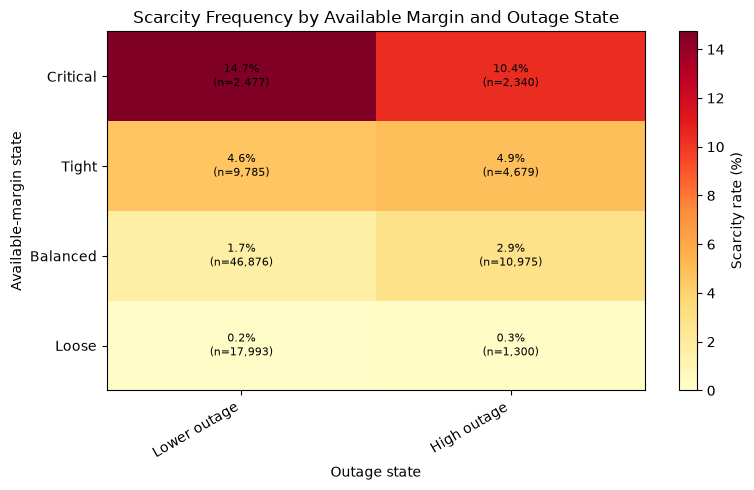

In [30]:
# ---------------------------------------------------------------------
# Available margin and outage interaction
# ---------------------------------------------------------------------

margin_outage_summary = build_conditional_summary(
    scarcity_features["margin_state"],
    scarcity_features["outage_state"],
    primary_event,
)

display(margin_outage_summary.round(3))

plot_conditional_heatmap(
    margin_outage_summary,
    row_order=MARGIN_STATE_ORDER,
    column_order=[
        "Lower outage",
        "High outage",
    ],
    title=(
        "Scarcity Frequency by Available Margin "
        "and Outage State"
    ),
    row_label="Available-margin state",
    column_label="Outage state",
)

#### Margin State x Outages

Scarcity generally becomes more frequent when high outages occur alongside tight or balanced available margins. Under balanced conditions, the scarcity rate rises from 1.7% during lower-outage hours to 2.9% during high-outage hours. Under loose conditions, scarcity remains rare regardless of outage state.

An apparent reversal occurs within the critical-margin state: scarcity affects 14.7% of lower-outage hours compared with 10.4% of high-outage hours. This does not indicate that outages reduce scarcity. Available margin already reflects reported generation availability, so conditioning on critical margin compares different mechanisms through which the system became tight. Critical hours with lower outages may instead be driven by exceptionally high net load, weak renewable generation, import limitations, or other forms of supply pressure.

Overall, outages appear to increase scarcity primarily by contributing to tighter available margins. Once margins are already critical, other operating conditions may become more important than whether outage levels are unusually high.

### 6.3 Margin State x Intertie Capability

,row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,Critical,Constrained,823,0.175,11,8.977,8,31,True
1,Critical,Typical,2854,0.146,11,8.858,11,66,True
2,Critical,High capability,1140,0.041,10,0.074,9,37,True
3,Tight,Constrained,2623,0.088,11,2.944,11,58,True
4,Tight,Typical,8595,0.046,11,1.846,11,548,True
5,Tight,High capability,3246,0.017,11,0.124,10,144,True
6,Balanced,Constrained,10969,0.040,11,0.678,11,840,True
7,Balanced,Typical,35250,0.018,11,0.241,11,2696,True
8,Balanced,High capability,11632,0.003,11,0.042,11,579,True
9,Loose,Constrained,5000,0.004,11,0.000,11,212,True


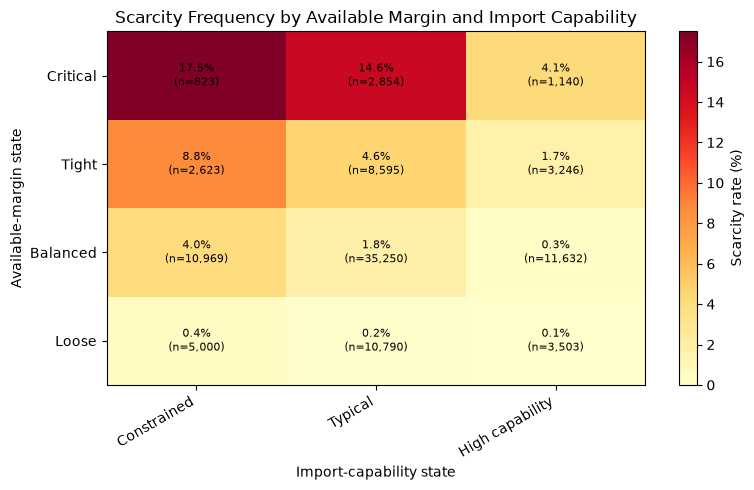

In [31]:
# ---------------------------------------------------------------------
# Available margin and import-capability interaction
# ---------------------------------------------------------------------

margin_capability_summary = build_conditional_summary(
    scarcity_features["margin_state"],
    scarcity_features["capability_state"],
    primary_event,
)

display(margin_capability_summary.round(3))

plot_conditional_heatmap(
    margin_capability_summary,
    row_order=MARGIN_STATE_ORDER,
    column_order=CAPABILITY_STATE_ORDER,
    title=(
        "Scarcity Frequency by Available Margin "
        "and Import Capability"
    ),
    row_label="Available-margin state",
    column_label="Import-capability state",
)

#### Margin State x Intertie Capability

Scarcity is most frequent when limited domestic available margin coincides with constrained import capability. During critical-margin hours, the scarcity rate declines from 17.5% under constrained capability to 14.6% under typical capability and 4.1% under high capability. The same ordered relationship appears under tight margins, where scarcity falls from 8.8% to 4.6% and then 1.7% as capability improves.

Import capability remains informative under balanced conditions: scarcity affects 4.0% of constrained-capability hours, compared with 1.8% under typical capability and 0.3% when capability is high. Under loose domestic margins, scarcity remains below 0.5% regardless of external capability.

The median annual lifts reinforce this interaction. Critical margins combined with constrained or typical capability produce the strongest and most persistent elevation over annual base rates. Overall, domestic margin and import capability provide complementary indicators of system tightness, although the contemporaneous results do not establish that higher capability independently causes lower scarcity.

### 6.4 Net-Load Decile x Outage Decile

row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,0,176,0.000,11,NaN,1,63,False
0,1,290,0.000,11,0.000,5,28,True
0,2,514,0.000,11,0.000,10,26,True
0,3,656,0.000,11,0.000,11,27,True
0,4,789,0.000,11,0.000,11,49,True
0,5,1186,0.000,11,0.000,11,51,True
0,6,1247,0.000,11,0.000,11,85,True
0,7,1335,0.000,11,0.000,11,94,True
0,8,1543,0.000,11,0.000,11,77,True
0,9,1898,0.000,11,0.000,11,99,True


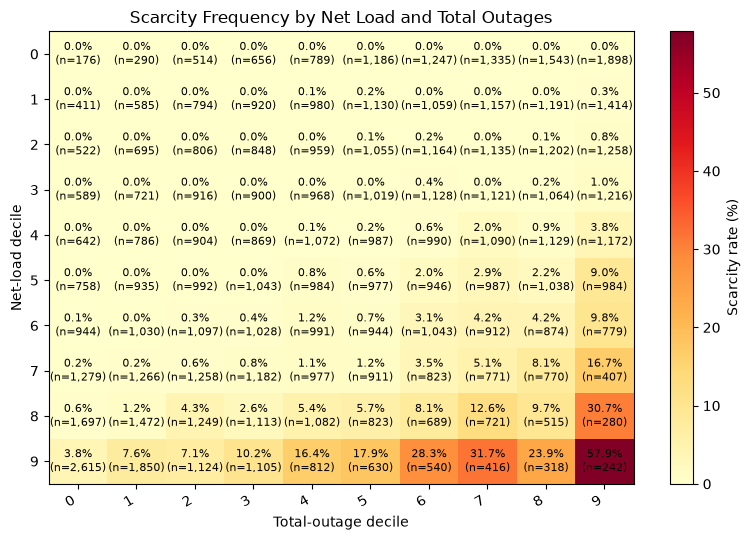

In [32]:
# ---------------------------------------------------------------------
# Net-load and outage interaction
# ---------------------------------------------------------------------

from IPython.display import HTML

net_load_outage_summary = build_conditional_summary(
    scarcity_features["net_load_decile"],
    scarcity_features["total_outage_decile"],
    primary_event,
)

display(
    HTML(
        f"""
        <div style="
            max-height: 500px;
            overflow-x: auto;
            overflow-y: auto;
        ">
            {
                net_load_outage_summary
                .round(3)
                .to_html(index=False)
            }
        </div>
        """
    )
)

plot_conditional_heatmap(
    net_load_outage_summary,
    row_order=list(range(10)),
    column_order=list(range(10)),
    title=(
        "Scarcity Frequency by Net Load "
        "and Total Outages"
    ),
    row_label="Net-load decile",
    column_label="Total-outage decile",
)

#### Net-Load Decile x Outage Decile

Scarcity is strongly concentrated in hours when high net load coincides with elevated outages. Outages alone are not sufficient to produce scarcity: throughout the lower net-load deciles, scarcity remains close to zero even when outages are in their highest deciles. The outage relationship becomes increasingly pronounced as net load moves into its upper tail.

Within the highest net-load decile, the scarcity rate rises from 3.8% in the lowest outage decile to 28.3% in outage decile 6 and 57.9% when both variables are in their highest deciles. A similar interaction appears in net-load deciles 7 and 8, where scarcity becomes progressively more frequent as outages increase.

The highest joint state contains 242 pooled hours and appears in nine years, with a scarcity rate of 57.9%. However, only three years meet the minimum annual sample requirement, so a stable median annual lift is not reported for this cell. The result therefore provides strong pooled evidence of an interaction between high net load and high outages, but insufficient support for a precise claim about its annual stability.

### 6.5 Thermal-Headroom Decile x Import-Flow Decile

row_state,column_state,hours,scarcity_rate,years_observed,median_annual_lift,years_qualifying,minimum_qualifying_year_hours,annual_stability_supported
0,0,756,0.090,11,3.635,6,78,True
0,1,601,0.143,10,3.470,7,51,True
0,2,568,0.042,11,0.992,8,32,True
0,3,606,0.071,11,0.844,9,27,True
0,4,664,0.187,10,6.165,9,31,True
0,5,674,0.217,11,4.643,10,25,True
0,6,916,0.158,10,4.646,9,55,True
0,7,1241,0.239,11,7.448,11,29,True
0,8,1358,0.225,11,5.844,11,30,True
0,9,1553,0.251,11,12.622,11,37,True


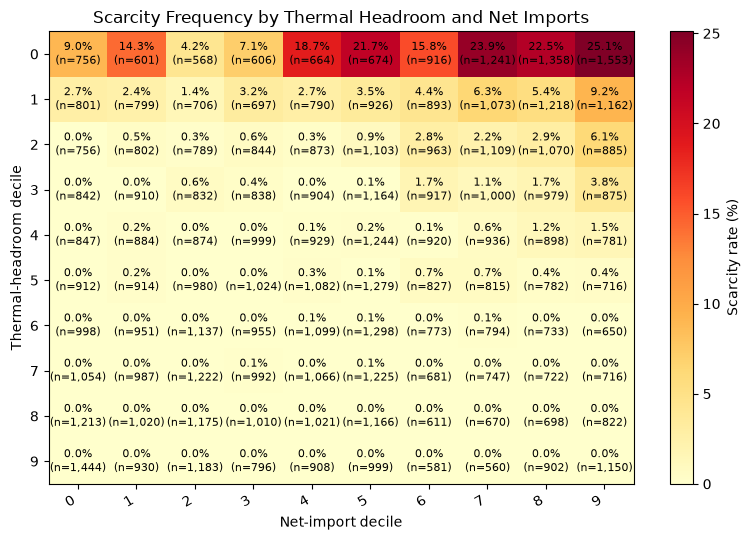

In [33]:
# ---------------------------------------------------------------------
# Thermal headroom and observed import-flow interaction
# ---------------------------------------------------------------------

headroom_import_summary = build_conditional_summary(
    scarcity_features["thermal_headroom_decile"],
    scarcity_features["net_imports_decile"],
    primary_event,
)

display(
    HTML(
        f"""
        <div style="
            max-height: 500px;
            overflow-x: auto;
            overflow-y: auto;
        ">
            {
                headroom_import_summary
                .round(3)
                .to_html(index=False)
            }
        </div>
        """
    )
)

plot_conditional_heatmap(
    headroom_import_summary,
    row_order=list(range(10)),
    column_order=list(range(10)),
    title=(
        "Scarcity Frequency by Thermal Headroom "
        "and Net Imports"
    ),
    row_label="Thermal-headroom decile",
    column_label="Net-import decile",
)

#### Thermal-Headroom Decile x Import-Flow Decile

Scarcity is strongly concentrated in the lowest thermal-headroom deciles. When thermal headroom is in its lowest decile, scarcity rates range from 4.2% to 25.1% across net-import states. The highest joint rate occurs when thermal headroom is lowest and net imports are highest, producing a 25.1% scarcity rate and a median annual lift of 12.6.

Scarcity declines rapidly as thermal headroom improves. Even within the highest net-import decile, the scarcity rate falls from 25.1% in the lowest headroom decile to 9.2% in the second, 6.1% in the third, and effectively zero in the upper headroom deciles. This indicates that adequate thermal headroom is associated with very little scarcity regardless of observed import flow.

Higher imports do not correspond to lower contemporaneous scarcity within the most constrained headroom states. This likely reflects the endogenous nature of observed flows: imports increase in response to high Alberta prices and tight domestic supply. Imports may still mitigate scarcity, but this contemporaneous comparison cannot estimate what prices would have been without them.

### 6.6 Compact Feature Screening

ROC AUC is retained as a compact descriptive screening statistic, but it is not the notebook’s main evidence.

Each feature is evaluated using:

- overall ROC AUC;
- precision-recall AUC;
- top-tail scarcity lift;
- annual AUC interquartile range;
- annual direction consistency;
- structural-regime AUC; and
- available sample coverage.

Features expected to reduce scarcity when they increase are sign-adjusted before evaluation. These scores measure contemporaneous separation, not forecast performance.

In [34]:
# ---------------------------------------------------------------------
# Feature-screening helper
# ---------------------------------------------------------------------

def screen_feature(
    feature_name,
    values,
    direction,
    event,
):
    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "structural_regime": structural_regime,
        "value": values,
        "event": event,
    }).dropna()

    if direction == "higher":
        score = frame["value"]
    elif direction == "lower":
        score = -frame["value"]
    else:
        raise ValueError(
            "direction must be 'higher' or 'lower'"
        )

    overall_auc = roc_auc_score(
        frame["event"],
        score,
    )

    precision_recall_auc = (
        average_precision_score(
            frame["event"],
            score,
        )
    )

    # For average precision, the no-skill reference
    # is the event prevalence in the evaluated sample.
    scarcity_prevalence = frame["event"].mean()

    tail_cutoff = score.quantile(0.90)

    tail_event_rate = frame.loc[
        score.ge(tail_cutoff),
        "event",
    ].mean()

    top_tail_lift = (
        tail_event_rate / scarcity_prevalence
        if scarcity_prevalence > 0
        else np.nan
    )

    annual_auc_values = []

    for year, group in frame.groupby(
        "year_alberta"
    ):
        if group["event"].nunique() < 2:
            continue

        group_score = (
            group["value"]
            if direction == "higher"
            else -group["value"]
        )

        annual_auc_values.append(
            roc_auc_score(
                group["event"],
                group_score,
            )
        )

    regime_auc_rows = []

    for regime, group in frame.groupby(
        "structural_regime",
        observed=True,
    ):
        if group["event"].nunique() < 2:
            continue

        group_score = (
            group["value"]
            if direction == "higher"
            else -group["value"]
        )

        regime_auc_rows.append({
            "feature": feature_name,
            "structural_regime": regime,
            "roc_auc": roc_auc_score(
                group["event"],
                group_score,
            ),
            "observations": len(group),
        })

    annual_auc_values = np.asarray(
        annual_auc_values,
        dtype=float,
    )

    overall_row = {
        "feature": feature_name,
        "expected_scarcity_direction": direction,
        "overall_roc_auc": overall_auc,
        "precision_recall_auc":
            precision_recall_auc,
        "overall_scarcity_prevalence":
            scarcity_prevalence,
        "pr_auc_lift_over_prevalence": (
            precision_recall_auc
            / scarcity_prevalence
            if scarcity_prevalence > 0
            else np.nan
        ),
        "top_tail_scarcity_lift":
            top_tail_lift,
        "annual_auc_25th_percentile":
            np.nanquantile(
                annual_auc_values,
                0.25,
            ),
        "annual_auc_75th_percentile":
            np.nanquantile(
                annual_auc_values,
                0.75,
            ),
        "annual_direction_consistency_pct":
            (
                np.mean(
                    annual_auc_values >= 0.50
                )
                * 100
            ),
        "coverage_pct":
            len(frame) / len(master) * 100,
    }

    return (
        overall_row,
        regime_auc_rows,
    )

In [35]:
# ---------------------------------------------------------------------
# Screen the main physical driver families
# ---------------------------------------------------------------------

SCREENING_FEATURES = {
    "Net load": (
        scarcity_features["net_load_mw"],
        "higher",
    ),

    "Reported capacity margin": (
        scarcity_features[
            "reported_capacity_margin_mw"
        ],
        "lower",
    ),

    "Domestic available margin": (
        scarcity_features[
            "domestic_available_margin_mw"
        ],
        "lower",
    ),

    "Thermal headroom": (
        scarcity_features[
            "thermal_headroom_mw"
        ],
        "lower",
    ),

    "Thermal utilization": (
        scarcity_features[
            "thermal_utilization_pct"
        ],
        "higher",
    ),

    "Total outages": (
        master["total_outage_mw"],
        "higher",
    ),

    "Relative outage burden": (
        scarcity_features[
            "outage_share_of_capacity_pct"
        ],
        "higher",
    ),

    "Observed net imports": (
        master["net_imports_mw"],
        "higher",
    ),

    "Reported import capability": (
        scarcity_features["import_atc_mw"],
        "lower",
    ),
}

screening_rows = []
regime_auc_rows = []

for feature_name, (
    values,
    direction,
) in SCREENING_FEATURES.items():

    overall_row, feature_regime_rows = (
        screen_feature(
            feature_name,
            values,
            direction,
            primary_event,
        )
    )

    screening_rows.append(overall_row)

    regime_auc_rows.extend(
        feature_regime_rows
    )

feature_screening = (
    pd.DataFrame(screening_rows)
    .sort_values(
        "overall_roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Keep precision-recall AUC directly beside its
# no-skill reference level in the displayed table.
FEATURE_SCREENING_COLUMN_ORDER = [
    "feature",
    "expected_scarcity_direction",
    "overall_roc_auc",
    "precision_recall_auc",
    "overall_scarcity_prevalence",
    "pr_auc_lift_over_prevalence",
    "top_tail_scarcity_lift",
    "annual_auc_25th_percentile",
    "annual_auc_75th_percentile",
    "annual_direction_consistency_pct",
    "coverage_pct",
]

feature_screening = feature_screening[
    FEATURE_SCREENING_COLUMN_ORDER
]

regime_auc_screening = pd.DataFrame(
    regime_auc_rows
)

display(feature_screening.round(3))

display(
    regime_auc_screening
    .pivot(
        index="feature",
        columns="structural_regime",
        values="roc_auc",
    )
    .reindex(columns=STRUCTURAL_REGIME_ORDER)
    .round(3)
)

,feature,expected_scarcity_direction,overall_roc_auc,precision_recall_auc,overall_scarcity_prevalence,pr_auc_lift_over_prevalence,top_tail_scarcity_lift,annual_auc_25th_percentile,annual_auc_75th_percentile,annual_direction_consistency_pct,coverage_pct
0,Thermal headroom,lower,0.898,0.183,0.025,7.263,6.082,0.917,0.980,100.000,100.000
1,Thermal utilization,higher,0.876,0.143,0.025,5.678,5.053,0.928,0.968,100.000,100.000
2,Net load,higher,0.828,0.148,0.025,5.857,4.448,0.815,0.900,100.000,100.000
3,Observed net imports,higher,0.754,0.053,0.025,2.113,2.197,0.703,0.833,100.000,96.198
4,Total outages,higher,0.633,0.039,0.025,1.538,1.527,0.595,0.788,100.000,100.000
5,Reported import capability,lower,0.614,0.045,0.025,1.782,2.119,0.416,0.707,63.636,100.000
6,Relative outage burden,higher,0.601,0.037,0.025,1.452,1.514,0.570,0.790,100.000,100.000
7,Domestic available margin,lower,0.585,0.049,0.025,1.959,2.431,0.820,0.956,100.000,100.000
8,Reported capacity margin,lower,0.527,0.044,0.025,1.755,1.654,0.675,0.794,100.000,100.000


structural_regime,Coal-dominant,Coal-to-gas transition,Late coal exit and renewable buildout,Coal-free gas-renewable system
feature,,,,
Domestic available margin,0.904,0.893,0.738,0.843
Net load,0.762,0.862,0.849,0.880
Observed net imports,0.919,0.743,0.730,0.926
Relative outage burden,0.833,0.654,0.585,0.694
Reported capacity margin,0.682,0.770,0.685,0.664
Reported import capability,0.518,0.489,0.622,0.776
Thermal headroom,0.904,0.925,0.943,0.951
Thermal utilization,0.855,0.921,0.939,0.960
Total outages,0.827,0.660,0.507,0.694


In [36]:
# ---------------------------------------------------------------------
# Test thermal-headroom sensitivity to the dual-fuel reporting gap
# ---------------------------------------------------------------------

thermal_headroom_sensitivity_frame = (
    pd.DataFrame({
        "event": primary_event,
        "thermal_headroom_mw":
            scarcity_features[
                "thermal_headroom_mw"
            ],
        "dual_fuel_reporting_gap":
            scarcity_features[
                "dual_fuel_reporting_gap"
            ],
    })
    .dropna(
        subset=[
            "event",
            "thermal_headroom_mw",
        ]
    )
)

complete_sample_auc = roc_auc_score(
    thermal_headroom_sensitivity_frame[
        "event"
    ],
    -thermal_headroom_sensitivity_frame[
        "thermal_headroom_mw"
    ],
)

gap_excluded_frame = (
    thermal_headroom_sensitivity_frame.loc[
        ~thermal_headroom_sensitivity_frame[
            "dual_fuel_reporting_gap"
        ]
    ]
)

gap_excluded_auc = roc_auc_score(
    gap_excluded_frame["event"],
    -gap_excluded_frame[
        "thermal_headroom_mw"
    ],
)

thermal_headroom_sensitivity = pd.DataFrame([
    {
        "sample": "Complete sample",
        "observations": len(
            thermal_headroom_sensitivity_frame
        ),
        "scarcity_hours": int(
            thermal_headroom_sensitivity_frame[
                "event"
            ].sum()
        ),
        "thermal_headroom_roc_auc":
            complete_sample_auc,
    },
    {
        "sample": (
            "Excluding dual-fuel reporting gap"
        ),
        "observations": len(
            gap_excluded_frame
        ),
        "scarcity_hours": int(
            gap_excluded_frame[
                "event"
            ].sum()
        ),
        "thermal_headroom_roc_auc":
            gap_excluded_auc,
    },
])

thermal_headroom_sensitivity[
    "change_from_complete_sample"
] = (
    thermal_headroom_sensitivity[
        "thermal_headroom_roc_auc"
    ]
    - complete_sample_auc
)

display(
    thermal_headroom_sensitivity.round(3)
)

,sample,observations,scarcity_hours,thermal_headroom_roc_auc,change_from_complete_sample
0,Complete sample,96425,2430,0.898,0.000
1,Excluding dual-fuel reporting gap,90642,1973,0.899,0.001


#### Compact Feature Screening

Thermal headroom is the strongest individual scarcity indicator. It produces an overall ROC-AUC of 0.898, a precision-recall AUC of 0.183 against a no-skill prevalence of 0.025, and a high-risk-tail scarcity lift of 6.08. Its precision-recall performance is therefore approximately 7.3 times the no-skill reference level. Its direction is consistent in every year, while its regime-specific ROC-AUC rises from 0.904 in the coal-dominant period to 0.951 in the coal-free gas-renewable system. Thermal utilization provides similarly strong and stable separation. Net load ranks third, with an overall ROC-AUC of 0.828 and consistently strong performance across structural regimes.

Observed net imports provide moderate discrimination, with an overall ROC-AUC of 0.754. However, observed flows can respond contemporaneously to system conditions and should not be interpreted as an independently causal or automatically forecast-eligible signal. Total outages and relative outage burden provide weaker separation, and their performance varies across regimes. Most notably, the ROC-AUC for total outages falls to approximately 0.51 during the late coal-exit and renewable-buildout period, indicating almost no unconditional separation within that regime.

Domestic available margin presents an important aggregation result. Its pooled ROC-AUC is only 0.585, despite substantially stronger annual and regime-specific scores. This divergence is consistent with long-term shifts in fleet composition, availability reporting, variable scale, and scarcity incidence obscuring the within-period relationship when all years are pooled. Reported capacity margin displays a similar but weaker discrepancy between pooled and within-period performance. Reported import capability is the least stable indicator, matching its expected scarcity direction in only 63.6% of evaluated years.

Overall, operational measures of thermal tightness and net load provide substantially stronger and more stable scarcity separation than reported capacity, outages, or import capability alone. These results are descriptive and contemporaneous: they measure how well individual variables separate scarcity from non-scarcity hours in the observed sample, not causal effects or out-of-sample forecasting performance.

Dual-fuel reporting is missing for 5,783 hours from March 8 through November 4, 2022. Because the thermal aggregation uses the available technology-level observations without imputing missing values, dual-fuel availability and generation are omitted from the reported thermal totals during this interval.

Excluding the affected hours changes thermal headroom’s ROC-AUC only from 0.898 to 0.899. The primary conclusion is therefore robust to the dual-fuel reporting gap. The affected observations remain flagged because the reported thermal totals are not fully comparable during that interval, but no synthetic dual-fuel values are introduced.

## 7. Scarcity Episodes and Event Persistence

### 7.1 Consecutive Scarcity Episodes

Consecutive hours at or above \$500/MWh are grouped into scarcity episodes. This prevents a multi-hour event from being treated as several unrelated observations.

Episodes are summarized by duration, peak price, integrated price excess, load, available margin, thermal headroom, outages, and imports.

In [37]:
# ---------------------------------------------------------------------
# Construct consecutive scarcity episodes
# ---------------------------------------------------------------------

episode_start = (
    primary_event
    & ~primary_event.shift(fill_value=False)
)

episode_id = (
    episode_start
    .cumsum()
    .where(primary_event)
)

episode_hourly = pd.DataFrame({
    "episode_id": episode_id,

    "timestamp_alberta":
        master["timestamp_alberta"],

    "pool_price":
        master["pool_price"],

    "price_excess": (
        master["pool_price"]
        - PRIMARY_SCARCITY_THRESHOLD
    ).clip(lower=0),

    "ail_mw":
        master["ail_mw"],

    "net_load_mw":
        scarcity_features["net_load_mw"],

    "available_margin_mw":
        scarcity_features[
            "domestic_available_margin_mw"
        ],

    "thermal_headroom_mw":
        scarcity_features[
            "thermal_headroom_mw"
        ],

    "total_outage_mw":
        master["total_outage_mw"],

    "net_imports_mw":
        master["net_imports_mw"],
}).dropna(subset=["episode_id"])

scarcity_episodes = (
    episode_hourly
    .groupby("episode_id")
    .agg(
        start=("timestamp_alberta", "min"),
        end=("timestamp_alberta", "max"),
        duration_hours=("timestamp_alberta", "size"),
        peak_price=("pool_price", "max"),
        average_price=("pool_price", "mean"),
        integrated_price_excess=(
            "price_excess",
            "sum",
        ),
        peak_load_mw=("ail_mw", "max"),
        peak_net_load_mw=("net_load_mw", "max"),
        minimum_available_margin_mw=(
            "available_margin_mw",
            "min",
        ),
        minimum_thermal_headroom_mw=(
            "thermal_headroom_mw",
            "min",
        ),
        maximum_total_outage_mw=(
            "total_outage_mw",
            "max",
        ),
        average_net_imports_mw=(
            "net_imports_mw",
            "mean",
        ),
    )
)

scarcity_episodes["start_year"] = (
    scarcity_episodes["start"].dt.year
)

scarcity_episodes = (
    scarcity_episodes
    .sort_values(
        [
            "integrated_price_excess",
            "duration_hours",
            "peak_price",
        ],
        ascending=False,
    )
)

print(
    f"Identified {len(scarcity_episodes):,} "
    f"consecutive scarcity episodes."
)

episode_preview = scarcity_episodes.head(20).copy()

numeric_columns = episode_preview.select_dtypes(
    include="number"
).columns

episode_preview[numeric_columns] = (
    episode_preview[numeric_columns].round(2)
)

display(episode_preview)

Identified 758 consecutive scarcity episodes.


,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
236.0,2021-12-27 09:00:00-07:00,2021-12-28 01:00:00-07:00,17,999.99,933.53,7370.07,11508,10951.94,657.0,1649.08,4958.4,490.12,2021
129.0,2020-01-13 06:00:00-07:00,2020-01-13 22:00:00-07:00,17,999.99,894.80,6711.55,11693,11627.94,60.0,1671.34,3915.4,811.59,2020
337.0,2022-09-13 23:00:00-06:00,2022-09-14 23:00:00-06:00,25,938.95,758.62,6465.41,9994,9538.08,2391.0,2148.59,4528.4,396.20,2022
131.0,2020-01-15 04:00:00-07:00,2020-01-15 21:00:00-07:00,18,999.60,854.49,6380.85,11562,11504.91,198.0,1910.31,3882.4,920.72,2020
650.0,2024-01-14 05:00:00-07:00,2024-01-14 22:00:00-07:00,18,999.99,847.64,6257.48,11669,11535.82,2712.0,2172.08,5980.4,13.78,2024
132.0,2020-01-16 06:00:00-07:00,2020-01-16 20:00:00-07:00,15,999.99,913.29,6199.28,11522,11508.31,351.0,2030.72,3978.4,967.33,2020
429.0,2022-12-21 05:00:00-07:00,2022-12-21 21:00:00-07:00,17,999.99,848.88,5930.93,12193,11628.33,1364.0,2181.36,4525.4,593.88,2022
647.0,2024-01-12 06:00:00-07:00,2024-01-12 21:00:00-07:00,16,999.99,869.06,5904.95,12091,12085.21,3038.0,2212.68,5297.4,443.44,2024
427.0,2022-12-20 00:00:00-07:00,2022-12-20 21:00:00-07:00,22,999.99,764.50,5819.10,12101,12025.80,2385.0,2250.86,3472.4,450.36,2022


#### Consecutive Scarcity Episodes

The hourly scarcity observations form 758 distinct consecutive episodes. The most severe episodes are not isolated one-hour price spikes: the leading events generally persist for 10–25 consecutive hours, with average prices frequently exceeding $800/MWh and peak prices approaching the historical price cap.

The largest cumulative event occurred in December 2021, lasting 17 hours with an average price of $933.53/MWh. Other major episodes cluster in January 2020, summer and winter 2022, summer 2023, and January 2024. Several occur on successive days, indicating that prolonged system stress can produce repeated episodes separated by brief periods below the scarcity threshold.

High net load and limited thermal headroom are common across the most severe episodes, but outage and import conditions vary substantially. Some events coincide with high outages and limited imports, while others receive considerable external support. This variation indicates that Alberta’s most consequential scarcity episodes arise through multiple combinations of demand pressure, domestic availability, renewable output, outages, and intertie flows.

### 7.2 Frequency, Duration, and Persistence

In [38]:
# ---------------------------------------------------------------------
# Summarize episode frequency and persistence
# ---------------------------------------------------------------------

annual_episode_summary = (
    scarcity_episodes
    .groupby("start_year")
    .agg(
        episodes=("duration_hours", "size"),
        scarcity_hours=("duration_hours", "sum"),
        average_duration_hours=(
            "duration_hours",
            "mean",
        ),
        median_duration_hours=(
            "duration_hours",
            "median",
        ),
        maximum_duration_hours=(
            "duration_hours",
            "max",
        ),
        maximum_episode_price=(
            "peak_price",
            "max",
        ),
        integrated_price_excess=(
            "integrated_price_excess",
            "sum",
        ),
    )
)

display(annual_episode_summary.round(2))

,episodes,scarcity_hours,average_duration_hours,median_duration_hours,maximum_duration_hours,maximum_episode_price,integrated_price_excess
start_year,,,,,,,
2015,30,95,3.17,2.5,7,998.04,28954.30
2016,2,2,1.00,1.0,1,631.30,204.83
2017,4,6,1.50,1.0,3,999.99,2515.44
2018,39,102,2.62,2.0,10,999.99,27266.77
2019,52,116,2.23,1.0,12,999.99,27067.21
2020,20,102,5.10,3.0,18,999.99,32044.49
2021,95,310,3.26,2.0,17,999.99,61763.39
2022,198,758,3.83,2.0,25,999.99,179565.52
2023,202,606,3.00,2.0,14,999.99,124733.29


#### Frequency, Duration, and Persistence

Scarcity changed in both frequency and persistence over the study period. Events were exceptionally uncommon in 2016 and 2017, followed by a moderate increase during 2018–2019. Although 2020 contained only 20 episodes, they lasted an average of 5.1 hours—the longest annual average in the sample—showing that relatively infrequent scarcity can still produce prolonged system stress.

Scarcity intensified sharply after 2020. The number of episodes increased to 95 in 2021 and approximately 200 in both 2022 and 2023. Conditions were most severe in 2022, with 758 scarcity hours, a maximum episode duration of 25 hours, and the highest integrated price-excess measure in the sample at approximately 179,566 \((\$/\text{MWh}) \times \text{hours}\). Although 2023 recorded slightly more episodes, they were shorter and produced fewer scarcity hours and lower integrated price excess.

Conditions moderated in 2024 and 2025, but scarcity remained more frequent than during most of the pre-2021 period. The annual maximum price reached or approached $1,000/MWh in nearly every year, making episode frequency, duration, and integrated price excess more informative measures of annual severity than the maximum price alone.

### 7.3 Event-Aligned Operating Profiles

Each episode is aligned at its first \$500/MWh hour. Median and interquartile-range profiles are calculated from 24 hours before onset through 12 hours afterward.

These profiles help distinguish three types of relationship:

- variables that deteriorate before the event;
- variables that change concurrently with event onset; and
- variables that respond only after scarcity is already underway.

The profiles remain descriptive because they use final contemporaneous observations.

In [39]:
# ---------------------------------------------------------------------
# Align physical variables around scarcity onset
# ---------------------------------------------------------------------

EVENT_WINDOW_START = -24
EVENT_WINDOW_END = 12

onset_positions = np.flatnonzero(
    episode_start.to_numpy()
)

aligned_rows = []

aligned_variables = {
    "Pool price":
        master["pool_price"],

    "Net load":
        scarcity_features["net_load_mw"],

    "Domestic available margin":
        scarcity_features[
            "domestic_available_margin_mw"
        ],

    "Thermal headroom":
        scarcity_features[
            "thermal_headroom_mw"
        ],

    "Total outages":
        master["total_outage_mw"],

    "Wind generation":
        master["wind_system_generation"],

    "Net imports":
        master["net_imports_mw"],
}

for episode_number, onset_position in enumerate(
    onset_positions,
    start=1,
):
    start_position = (
        onset_position + EVENT_WINDOW_START
    )
    end_position = (
        onset_position + EVENT_WINDOW_END
    )

    if start_position < 0:
        continue

    if end_position >= len(master):
        continue

    aligned_block = pd.DataFrame({
        variable_name:
            values.iloc[
                start_position:
                end_position + 1
            ].to_numpy()
        for variable_name, values
        in aligned_variables.items()
    })

    aligned_block["episode_number"] = (
        episode_number
    )

    aligned_block["relative_hour"] = np.arange(
        EVENT_WINDOW_START,
        EVENT_WINDOW_END + 1,
    )

    aligned_rows.append(aligned_block)

event_aligned = pd.concat(
    aligned_rows,
    ignore_index=True,
)

event_aligned_long = event_aligned.melt(
    id_vars=[
        "episode_number",
        "relative_hour",
    ],
    var_name="variable",
    value_name="value",
)

event_aligned_profile = (
    event_aligned_long
    .groupby(
        ["variable", "relative_hour"]
    )["value"]
    .agg(
        median="median",
        q25=lambda series:
            series.quantile(0.25),
        q75=lambda series:
            series.quantile(0.75),
        observations="count",
    )
    .reset_index()
)

display(event_aligned_profile.head())

,variable,relative_hour,median,q25,q75,observations
0,Domestic available margin,-24,3236.0,2081.50,4395.00,758
1,Domestic available margin,-23,3167.5,2088.75,4437.00,758
2,Domestic available margin,-22,3165.5,2081.75,4444.75,758
3,Domestic available margin,-21,3197.5,2149.50,4471.00,758
4,Domestic available margin,-20,3254.0,2192.00,4563.50,758


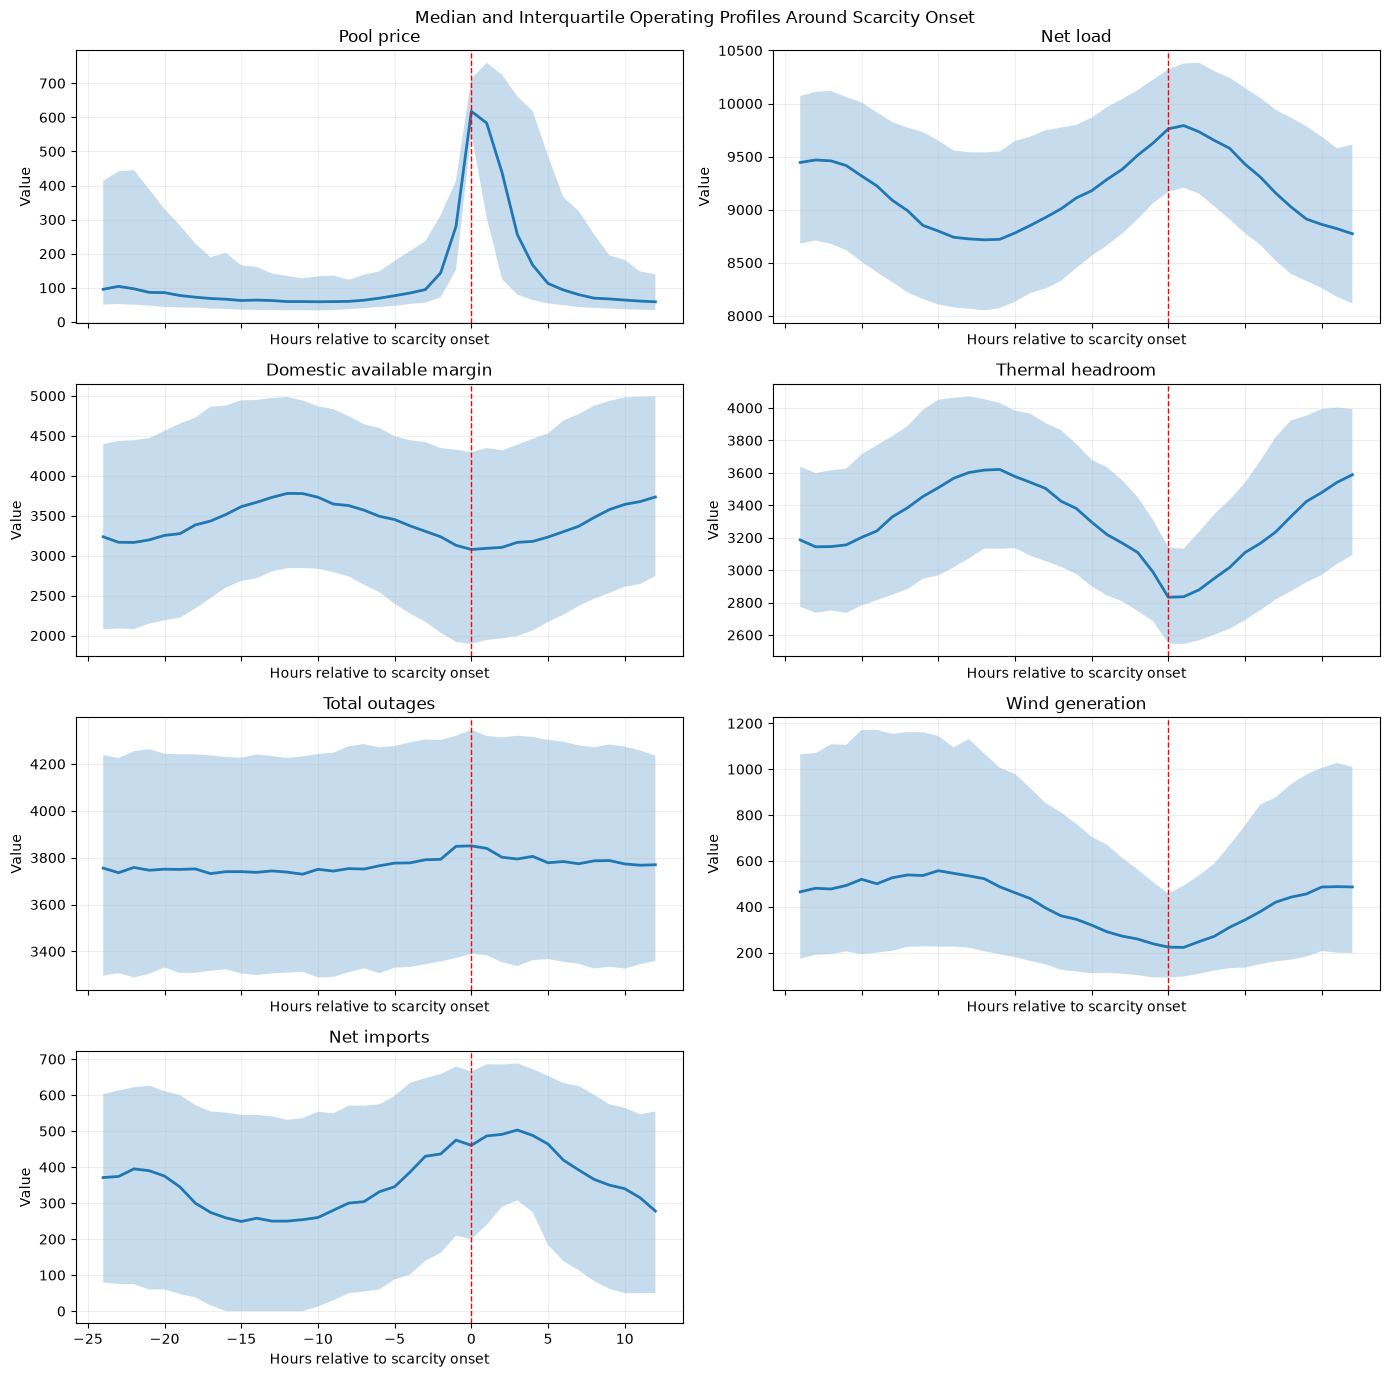

In [40]:
# ---------------------------------------------------------------------
# Plot median and interquartile event-aligned profiles
# ---------------------------------------------------------------------

profile_variables = list(
    aligned_variables.keys()
)

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 14),
    sharex=True,
)

for axis, variable in zip(
    axes.flatten(),
    profile_variables,
):
    plot_data = event_aligned_profile[
        event_aligned_profile[
            "variable"
        ].eq(variable)
    ]

    axis.plot(
        plot_data["relative_hour"],
        plot_data["median"],
        linewidth=2,
    )

    axis.fill_between(
        plot_data["relative_hour"],
        plot_data["q25"],
        plot_data["q75"],
        alpha=0.25,
    )

    axis.axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(variable)
    axis.set_xlabel("Hours relative to scarcity onset")
    axis.set_ylabel("Value")
    axis.grid(alpha=0.20)

unused_axes = (
    len(axes.flatten()) - len(profile_variables)
)

if unused_axes:
    for axis in axes.flatten()[-unused_axes:]:
        axis.set_visible(False)

fig.suptitle(
    "Median and Interquartile Operating Profiles "
    "Around Scarcity Onset"
)

plt.tight_layout()
plt.show()

#### Event-Aligned Operating Profiles

The 24-hour profiles around 758 scarcity onsets show a coordinated tightening of Alberta’s operating position. Net load rises steadily before onset and reaches its highest median level shortly afterward. Over the same period, wind generation declines, domestic available margin contracts, and thermal headroom falls sharply toward its minimum.

Observed net imports increase as domestic conditions tighten, rising before onset and peaking several hours afterward. This timing is consistent with imports responding to Alberta’s emerging supply pressure and elevated prices. Total outages, by contrast, change relatively little around onset, showing only a modest increase compared with the pronounced movements in net load and thermal headroom.

Pool price rises abruptly immediately before the event threshold is crossed and remains elevated during the first several scarcity hours before declining. Overall, the median episode develops through rising net demand, weakening renewable output, falling domestic and thermal margins, and increasing external support. The wide interquartile ranges indicate substantial variation across individual episodes, so these profiles describe the typical sequence rather than a universal event pathway.

### 7.4 Historical Case Studies

The most severe episodes are examined individually to determine whether they share a common physical profile or represent different scarcity mechanisms.

Severity is ranked by integrated price excess above \$500/MWh, followed by episode duration and peak price.

In [41]:
def plot_episode_case_study(
    selected_episode_id,
    hours_before=24,
    hours_after=24,
):
    selected = scarcity_episodes.loc[
        selected_episode_id
    ]

    window_start = (
        selected["start"]
        - pd.Timedelta(hours=hours_before)
    )

    window_end = (
        selected["end"]
        + pd.Timedelta(hours=hours_after)
    )

    window_mask = master[
        "timestamp_alberta"
    ].between(
        window_start,
        window_end,
    )

    window = pd.DataFrame({
        "timestamp": master.loc[
            window_mask,
            "timestamp_alberta",
        ],
        "pool_price": master.loc[
            window_mask,
            "pool_price",
        ],
        "available_margin": scarcity_features.loc[
            window_mask,
            "domestic_available_margin_mw",
        ],
        "thermal_headroom": scarcity_features.loc[
            window_mask,
            "thermal_headroom_mw",
        ],
        "total_outages": master.loc[
            window_mask,
            "total_outage_mw",
        ],
        "net_imports": master.loc[
            window_mask,
            "net_imports_mw",
        ],
    })

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(13, 11),
        sharex=True,
    )

    axes[0].plot(
        window["timestamp"],
        window["pool_price"],
    )
    axes[0].axhline(
        PRIMARY_SCARCITY_THRESHOLD,
        linestyle="--",
        linewidth=1,
    )
    axes[0].set_ylabel("Price\n($/MWh)")

    axes[1].plot(
        window["timestamp"],
        window["available_margin"],
        label="Available margin",
    )
    axes[1].plot(
        window["timestamp"],
        window["thermal_headroom"],
        label="Thermal headroom",
    )
    axes[1].set_ylabel("Margin\n(MW)")
    axes[1].legend()

    axes[2].plot(
        window["timestamp"],
        window["total_outages"],
    )
    axes[2].set_ylabel("Outages\n(MW)")

    axes[3].plot(
        window["timestamp"],
        window["net_imports"],
    )
    axes[3].axhline(
        0,
        linewidth=1,
    )
    axes[3].set_ylabel("Net imports\n(MW)")
    axes[3].set_xlabel("Alberta timestamp")

    for axis in axes:
        axis.axvspan(
            selected["start"],
            selected["end"],
            color="red",
            alpha=0.15,
        )
        axis.grid(alpha=0.20)

    fig.suptitle(
        "Scarcity Episode Beginning "
        f"{selected['start']}"
    )

    plt.tight_layout()
    plt.show()

    episode_summary = scarcity_episodes.loc[
        [selected_episode_id]
    ].copy()

    numeric_columns = episode_summary.select_dtypes(
        include="number"
    ).columns

    episode_summary[numeric_columns] = (
        episode_summary[numeric_columns].round(2)
    )

    display(episode_summary)

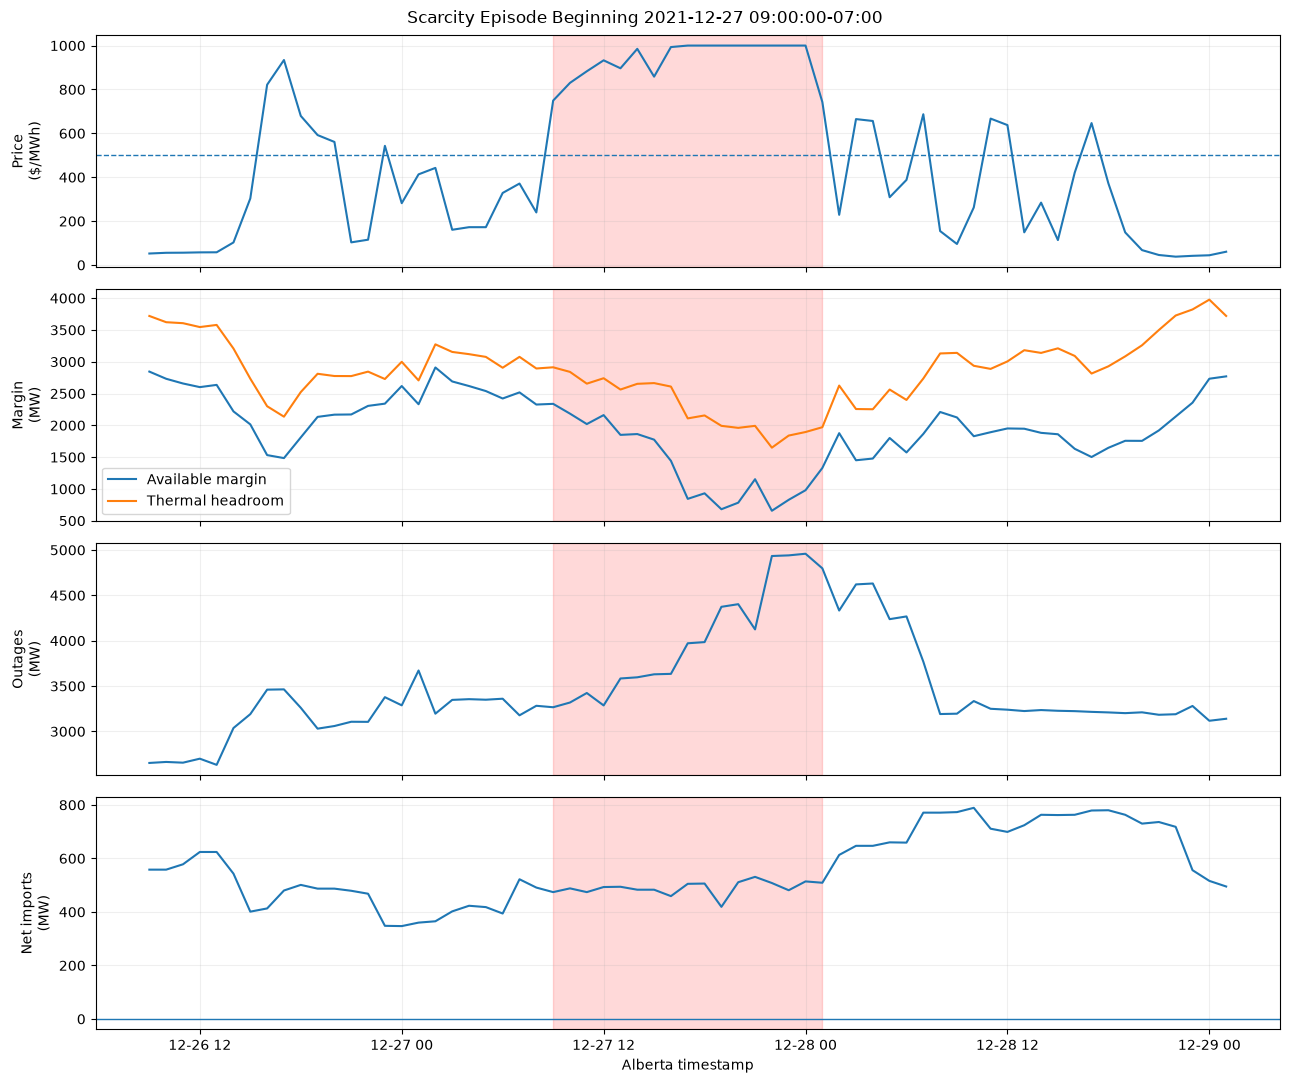

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
236.0,2021-12-27 09:00:00-07:00,2021-12-28 01:00:00-07:00,17,999.99,933.53,7370.07,11508,10951.94,657.0,1649.08,4958.4,490.12,2021


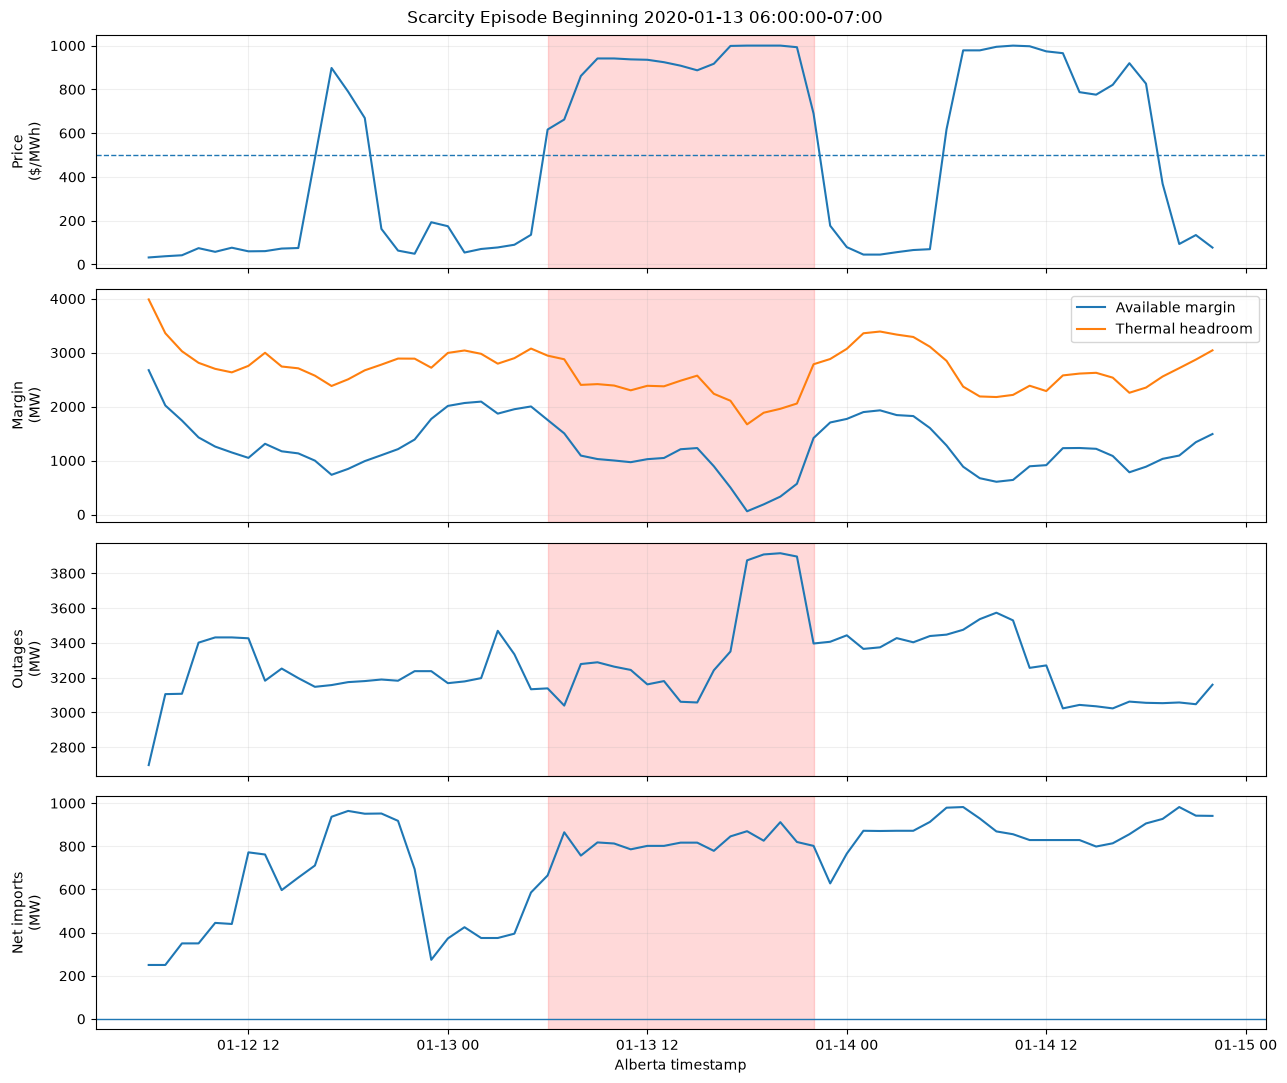

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
129.0,2020-01-13 06:00:00-07:00,2020-01-13 22:00:00-07:00,17,999.99,894.8,6711.55,11693,11627.94,60.0,1671.34,3915.4,811.59,2020


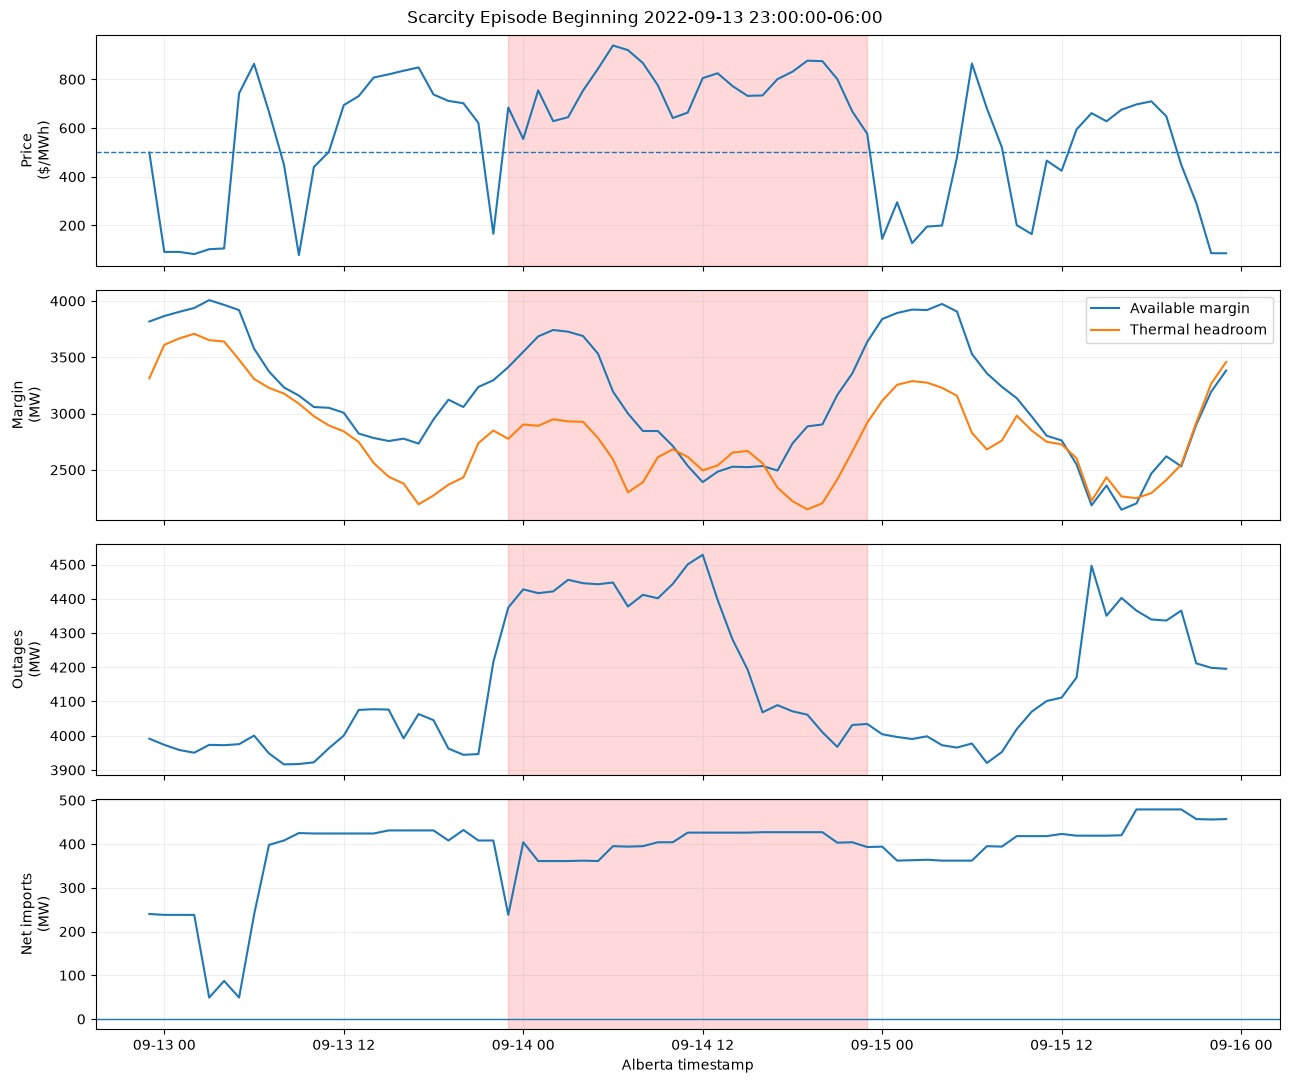

,start,end,duration_hours,peak_price,average_price,integrated_price_excess,peak_load_mw,peak_net_load_mw,minimum_available_margin_mw,minimum_thermal_headroom_mw,maximum_total_outage_mw,average_net_imports_mw,start_year
episode_id,,,,,,,,,,,,,
337.0,2022-09-13 23:00:00-06:00,2022-09-14 23:00:00-06:00,25,938.95,758.62,6465.41,9994,9538.08,2391.0,2148.59,4528.4,396.2,2022


In [42]:
# ---------------------------------------------------------------------
# Plot the three most severe historical episodes
# ---------------------------------------------------------------------

for selected_episode_id in scarcity_episodes.head(3).index:
    plot_episode_case_study(selected_episode_id)

#### Historical Case Studies

The three most severe episodes illustrate that prolonged scarcity can emerge through different combinations—and sequences—of system pressure.

The December 2021 episode combined extremely high prices with a severe deterioration in domestic supply conditions. During the 17-hour event, average price reached $933.53/MWh, available margin fell to 657 MW, thermal headroom declined to 1,649 MW, and outages approached 4,958 MW. The most severe price conditions broadly coincided with collapsing headroom and rising outages. Imports remained substantial during the event and increased further afterward as domestic margins began recovering.

The January 2020 episode represents the most acute available-margin constraint. Available margin fell to only 60 MW while thermal headroom declined to 1,671 MW. Outages rose sharply near the period of greatest margin compression, while pool price approached the price cap. Alberta averaged approximately 812 MW of net imports throughout the 17-hour event, indicating considerable reliance on external supply. A second major price increase followed shortly afterward, placing the episode within a broader period of persistent market stress.

The September 2022 episode followed a different sequence. Scarcity began while outages were already elevated but thermal headroom had not yet reached its minimum. As the 25-hour episode progressed, outages declined while thermal headroom continued to collapse, allowing scarcity to persist even as the initial outage pressure eased. Minimum available margin remained near 2,391 MW and thermal headroom near 2,149 MW—less extreme than in the winter cases—yet prices remained above the scarcity threshold for longer.

This contrast is analytically important. In the 2020 and 2021 episodes, peak scarcity aligned more directly with simultaneous margin compression, low thermal headroom, and elevated outages. In September 2022, the condition sustaining scarcity changed during the event: high outages were prominent at onset, while declining thermal headroom became more important later.

Together, the cases reinforce that thermal headroom and available margin are important scarcity indicators while also showing that no single threshold or static operating condition explains every severe episode. Duration and severity depend not only on the combination of domestic availability, outages, net demand, imports, and structural regime, but also on how those conditions evolve throughout an event.

### Section 7 Summary

The event analysis shows that scarcity onset is typically preceded by a coordinated tightening of Alberta’s operating position. Median net load rises during the hours before onset, while wind generation declines and domestic available margin contracts. Thermal headroom also deteriorates sharply toward the beginning of the event. These movements indicate that scarcity commonly develops through rising demand for dispatchable supply combined with diminishing domestic flexibility.

Outages follow a less uniform temporal pattern. The median outage profile changes relatively little around onset compared with net load, available margin, or thermal headroom. This does not make outages unimportant. Instead, it indicates that outages often establish the background conditions under which other pressures become binding. Individual episodes confirm that outages may be elevated before onset, rise during the event, or decline while another constraint begins sustaining scarcity.

Observed imports generally increase as domestic conditions tighten and peak after scarcity has begun. This timing is consistent with external supply responding to Alberta’s emerging system pressure and elevated prices. Imports may mitigate the severity of scarcity, but the contemporaneous profiles cannot estimate the counterfactual price that would have occurred without that support.

Thermal headroom remains one of the most consistent characteristics of multi-hour events. It typically falls before or around onset and remains compressed during the early scarcity hours. Its precise timing nevertheless varies by episode. In January 2020 and December 2021, the most severe prices broadly coincide with low headroom, compressed available margin, and elevated outages. In September 2022, scarcity begins while outages are already high but thermal headroom has not yet reached its minimum. The event persists as outages decline and thermal headroom continues to deteriorate.

The 758 identified episodes therefore do not represent one universal scarcity mechanism. Some events are dominated by exceptionally high net load, others by severe margin compression or elevated outages, and others by changing combinations of these conditions. The three most severe cases show that the constraint initiating an event need not be the same constraint that sustains it.

Overall, event onset is most consistently associated with rising net load, declining renewable output, falling available margin, and contracting thermal headroom. Imports generally respond as external support, while outages vary more substantially across episodes. Scarcity duration and severity depend both on the conditions present at onset and on how the system’s binding constraint evolves throughout the event.

## 8. Evidence Register

The notebook concludes with one compact evidence register. Each physical driver is classified using the following questions:

1. What is the direction of the relationship?
2. Is the relationship linear, threshold-based, or concentrated in a tail?
3. Does the driver remain associated with scarcity after stratifying by margin or net-load state?
4. Under what other operating conditions does it matter?
5. Is the direction stable across years and structural regimes?
6. Would the value have been known at the intended forecast origin?
7. Is it redundant with another variable?
8. Does it help explain event onset, severity, or persistence?

The register separates descriptive value from forecast eligibility. Strong contemporaneous relationships are not automatically forecast-ready.

In [43]:
# ---------------------------------------------------------------------
# Create the compact evidence register
# ---------------------------------------------------------------------

evidence_metadata = pd.DataFrame([
    {
        "feature": "Net load",
        "mechanism": "Demand remaining after wind and solar",
        "conditional_on": "Available margin and outages",
        "forecast_eligibility": (
            "Requires load and renewable forecasts"
        ),
        "redundant_with": pd.NA,
        "feature_role": "Primary",
        "destination": "Retain",
    },
    {
        "feature": "Reported capacity margin",
        "mechanism": "Nominal fleet size relative to load",
        "conditional_on": "Structural regime",
        "forecast_eligibility": (
            "Constructible from capacity and load forecasts"
        ),
        "redundant_with": pd.NA,
        "feature_role": "Benchmark",
        "destination": "Benchmark",
    },
    {
        "feature": "Domestic available margin",
        "mechanism": "Reported available supply relative to load",
        "conditional_on": "Structural regime",
        "forecast_eligibility": (
            "Requires forecast-vintage availability"
        ),
        "redundant_with": pd.NA,
        "feature_role": "Primary",
        "destination": "Retain",
    },
    {
        "feature": "Thermal headroom",
        "mechanism": "Unused reported thermal availability",
        "conditional_on": "Net load and available margin",
        "forecast_eligibility": (
            "Descriptive unless commitment is forecast"
        ),
        "redundant_with": "Thermal utilization",
        "feature_role": "Primary",
        "destination": "Conditional",
    },
    {
        "feature": "Thermal utilization",
        "mechanism": "Intensity of thermal fleet use",
        "conditional_on": "Net load and available margin",
        "forecast_eligibility": (
            "Descriptive unless dispatch is forecast"
        ),
        "redundant_with": "Thermal headroom",
        "feature_role": "Supporting",
        "destination": "Conditional",
    },
    {
        "feature": "Total outages",
        "mechanism": "Unavailable generation",
        "conditional_on": "Available margin and net load",
        "forecast_eligibility": (
            "Depends on outage-data vintage"
        ),
        "redundant_with": "Relative outage burden",
        "feature_role": "Primary",
        "destination": "Conditional",
    },
    {
        "feature": "Relative outage burden",
        "mechanism": "Outages relative to fleet size",
        "conditional_on": "Available margin",
        "forecast_eligibility": (
            "Depends on outage-data vintage"
        ),
        "redundant_with": "Total outages",
        "feature_role": "Supporting",
        "destination": "Conditional",
    },
    {
        "feature": "Observed net imports",
        "mechanism": (
            "External support responding to system stress"
        ),
        "conditional_on": "Margin and import capability",
        "forecast_eligibility": (
            "Requires an import forecast"
        ),
        "redundant_with": pd.NA,
        "feature_role": "Descriptive",
        "destination": "Descriptive only",
    },
    {
        "feature": "Reported import capability",
        "mechanism": (
            "Maximum reported external import support"
        ),
        "conditional_on": "Margin and regional conditions",
        "forecast_eligibility": (
            "Requires forecast-vintage capability"
        ),
        "redundant_with": pd.NA,
        "feature_role": "Primary",
        "destination": "Conditional",
    },
])

evidence_register = (
    evidence_metadata
    .merge(
        feature_screening,
        on="feature",
        how="left",
    )
)

evidence_register["annual_auc_iqr"] = (
    evidence_register[
        "annual_auc_75th_percentile"
    ]
    - evidence_register[
        "annual_auc_25th_percentile"
    ]
)

evidence_register = evidence_register[
    [
        "feature",
        "mechanism",
        "expected_scarcity_direction",
        "overall_roc_auc",
        "precision_recall_auc",
        "overall_scarcity_prevalence",
        "pr_auc_lift_over_prevalence",
        "top_tail_scarcity_lift",
        "annual_auc_iqr",
        "annual_direction_consistency_pct",
        "coverage_pct",
        "conditional_on",
        "forecast_eligibility",
        "redundant_with",
        "feature_role",
        "destination",
    ]
]

display(evidence_register.round(3))

,feature,mechanism,expected_scarcity_direction,overall_roc_auc,precision_recall_auc,overall_scarcity_prevalence,pr_auc_lift_over_prevalence,top_tail_scarcity_lift,annual_auc_iqr,annual_direction_consistency_pct,coverage_pct,conditional_on,forecast_eligibility,redundant_with,feature_role,destination
0,Net load,Demand remaining after wind and solar,higher,0.828,0.148,0.025,5.857,4.448,0.085,100.000,100.000,Available margin and outages,Requires load and renewable forecasts,NaN,Primary,Retain
1,Reported capacity margin,Nominal fleet size relative to load,lower,0.527,0.044,0.025,1.755,1.654,0.119,100.000,100.000,Structural regime,Constructible from capacity and load forecasts,NaN,Benchmark,Benchmark
2,Domestic available margin,Reported available supply relative to load,lower,0.585,0.049,0.025,1.959,2.431,0.137,100.000,100.000,Structural regime,Requires forecast-vintage availability,NaN,Primary,Retain
3,Thermal headroom,Unused reported thermal availability,lower,0.898,0.183,0.025,7.263,6.082,0.063,100.000,100.000,Net load and available margin,Descriptive unless commitment is forecast,Thermal utilization,Primary,Conditional
4,Thermal utilization,Intensity of thermal fleet use,higher,0.876,0.143,0.025,5.678,5.053,0.040,100.000,100.000,Net load and available margin,Descriptive unless dispatch is forecast,Thermal headroom,Supporting,Conditional
5,Total outages,Unavailable generation,higher,0.633,0.039,0.025,1.538,1.527,0.194,100.000,100.000,Available margin and net load,Depends on outage-data vintage,Relative outage burden,Primary,Conditional
6,Relative outage burden,Outages relative to fleet size,higher,0.601,0.037,0.025,1.452,1.514,0.219,100.000,100.000,Available margin,Depends on outage-data vintage,Total outages,Supporting,Conditional
7,Observed net imports,External support responding to system stress,higher,0.754,0.053,0.025,2.113,2.197,0.130,100.000,96.198,Margin and import capability,Requires an import forecast,NaN,Descriptive,Descriptive only
8,Reported import capability,Maximum reported external import support,lower,0.614,0.045,0.025,1.782,2.119,0.290,63.636,100.000,Margin and regional conditions,Requires forecast-vintage capability,NaN,Primary,Conditional


#### Evidence Register

The feature assessment separates historical scarcity discrimination from genuine forecast eligibility. Thermal headroom and thermal utilization provide the strongest contemporaneous separation, with ROC-AUC values of 0.898 and 0.876 and high-risk-tail lifts of 6.08 and 5.05. They are also highly stable across years. However, both depend on contemporaneous availability, commitment, and dispatch information, so they should remain conditional or descriptive unless those quantities can be forecast at the intended prediction origin.

Net load offers the strongest combination of discrimination, stability, and practical forecasting potential. It achieves an overall ROC-AUC of 0.828, maintains the expected direction in every year, and can be constructed from load, wind, and solar forecasts. Domestic available margin is also retained because its weaker pooled score conceals stronger within-year and within-regime relationships, although its use requires forecast-vintage availability data. Reported capacity margin provides limited discrimination and is best retained as a transparent benchmark.

Outage measures provide weaker standalone discrimination and appear most informative conditionally on available margin and net load. Observed net imports are informative historically but respond contemporaneously to system stress; they should not enter an ex-ante model unless replaced by a genuine import forecast. Import capability may provide conditional information, but its direction is less stable and its usefulness depends on access to forecast-vintage capability.

Overall, the strongest descriptive variables are not automatically the most appropriate forecasting features. The forecasting notebooks should prioritize variables that can be reproduced using information available before the target hour and treat contemporaneous operational measures as explanatory benchmarks or conditional candidates.

### Deferred Driver Families

The following mechanisms are intentionally excluded from Notebook 2:

| Driver family | Destination | Reason |
|---|---|---|
| Gas prices, heat rates and spark spreads | Notebook 3 | Fuel economics and marginal-generation costs |
| Offer behaviour and market rules | Notebook 3 | Translation of physical tightness into price |
| Temperature and demand formation | Notebook 4 | Weather-driven demand variation |
| Wind, solar and hydro weather relationships | Notebook 4 | Renewable availability and forecast errors |
| Calendar effects | Notebook 5 | Recurring temporal structure |
| Price lags and volatility clustering | Notebook 5 | Market memory and persistence |
| Formal feature selection and predictive models | Notebooks 6–8 | Time-based forecast evaluation |

Notebook 2 may use actual renewable output, imports, availability, and outages to explain historical events. It should not describe them as forecast signals until their information timing and forecast-vintage equivalents are evaluated.

## 9. Conclusion

This notebook evaluated Alberta electricity-price scarcity as the outcome of interacting demand, supply, margin, outage, and intertie conditions. The results show that scarcity is not explained by one universal threshold or operating variable. It emerges when several forms of system pressure coincide and can persist as the dominant constraint changes during an event.

**Demand pressure provides a stable foundation for the scarcity relationship.** Scarcity hours contain only moderately higher gross load but substantially higher net load because renewable generation is typically lower. Average net load is approximately 14.5% higher during scarcity, while variable renewable generation is approximately 49.6% lower. Net load produces an overall ROC-AUC of 0.828, a top-tail scarcity lift of 4.45, and the expected direction in every year and structural regime. Scarcity onset is also associated with pronounced net-load increases, particularly over the preceding six hours. Net load therefore provides a stronger and more stable description of demand pressure than gross load alone.

**Available supply matters more than nominal fleet size, although its relationship must be evaluated within comparable periods.** Reported capacity margin provides little pooled scarcity separation, with an ROC-AUC of 0.527. Domestic available margin also has a weak pooled score of 0.585, but its within-year and structural-regime relationships are substantially stronger. Scarcity occurs during 12.6% of critical-margin hours, compared with 4.7% of tight hours, 1.9% of balanced hours, and 0.2% of loose hours. The margin gradient persists across all four structural regimes, indicating that reported availability relative to load is more informative than nominal capacity alone. Forecast use would nevertheless require availability information that was genuinely available before the target hour.

**Thermal headroom is the strongest contemporaneous indicator of scarcity, while outages are more conditional.** Thermal headroom achieves an overall ROC-AUC of 0.898, the highest precision-recall performance, and a top-tail scarcity lift of 6.08. Thermal utilization provides a closely related supporting measure, although the two variables should not be interpreted as independent because both are constructed from thermal availability and generation. Total outages provide weaker standalone separation, with an ROC-AUC of 0.633, but become important when combined with elevated net load or compressed available margin. When both net load and outages are in their highest within-year deciles, the pooled scarcity rate reaches 57.9%. Outages therefore appear to amplify existing system pressure rather than produce scarcity uniformly across all operating conditions.

**Imports and import capability play different roles.** Observed net imports are considerably higher during scarcity and often rise as domestic conditions tighten. Their positive association with scarcity reflects external supply responding to Alberta price and system pressure; it should not be interpreted as evidence that imports cause scarcity. Reported import capability shows a more protective conditional relationship. Within critical-margin hours, scarcity declines from 17.5% under constrained capability to 4.1% under high capability. However, capability is less stable across years than net load or thermal headroom. Observed imports should therefore remain descriptive unless replaced by an import forecast, while import capability should remain a conditional candidate requiring forecast-vintage data.

**Scarcity episodes follow multiple physical pathways.** The analysis identifies 758 consecutive episodes at or above \$500/MWh. The typical onset is preceded by rising net load, declining wind generation, contracting available margin, and falling thermal headroom, while imports increase as external support responds. Total outages change less consistently in the median profile, but individual case studies reveal important variation. The January 2020 and December 2021 episodes aligned severe prices with simultaneous margin compression, low thermal headroom, and elevated outages. In September 2022, scarcity began while outages were high and continued as outages declined but thermal headroom deteriorated. Scarcity persistence therefore depends not only on the operating conditions present at onset but also on how the binding constraint evolves throughout the event.

Overall, net load offers the strongest combination of historical discrimination, structural stability, and practical forecasting potential. Domestic available margin should be retained where forecast-vintage availability can be constructed. Thermal headroom should remain the primary descriptive measure of thermal tightness, with thermal utilization treated as a related supporting indicator. Outages and import capability are best treated as conditional variables, while observed imports remain descriptive because they respond contemporaneously to system stress. Reported capacity margin provides a transparent but comparatively weak benchmark.

These findings establish the physical scarcity framework for the remainder of the project. Notebook 3 examines how fuel costs, offer behaviour, and market rules translate physical tightness into price. Notebook 4 investigates how weather creates demand and renewable conditions. Notebook 5 evaluates recurring temporal patterns and market memory. The later forecasting notebooks will determine which relationships remain useful when every feature is reconstructed using only information available before the forecast target.